In [1]:
import math
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from multiprocessing import Pool

# Введение в теорию хаоса: логистическое отображение #

В этом уроке мы исследуем одну из самых удивительных математических систем - 
**логистическое отображение**, простое итерационное уравнение, которое демонстрирует 
невероятно сложное поведение.

Мы увидим, как простая формула может порождать:
- Стабильные состояния
- Периодические колебания
- Каскады биффуркаций
- Детерминированный хаос

Это путешествие от порядка к хаосу продемонстрирует фундаментальные принципы 
нелинейной динамики и теории хаоса.

## Глава первая. История его жизни.

Начнем с простого наблюдения за поведением итерационного процесса 
и постепенно будем открывать его удивительные свойства.

Мы исследуем параметризованный итерационный процесс:

In [2]:
def process(x, a):
    return a * x * (1 - x)

Смоделируем 10 шагов функции:

In [3]:
def print_process(x0, a, steps, process):
    x = x0
    for _ in range(steps):
        print(round(x, 5), end=' ➔ ')
        x = process(x=x, a=a)

In [4]:
        # time.sleep(1)

print_process(x0=0.3, a=2, steps=10, process=process)

0.3 ➔ 0.42 ➔ 0.4872 ➔ 0.49967 ➔ 0.5 ➔ 0.5 ➔ 0.5 ➔ 0.5 ➔ 0.5 ➔ 0.5 ➔ 

Как видно, значение стабилизировалось на 0.5

Построим график процесса.

In [7]:
def draw_process_chart(x0, a, steps, process, every=1):
    """Функция рисования графика процесса"""
    x = x0
    xs = []
    for t in range(steps):
        if t%every == 0:
            xs.append(x)
        x = process(x, a)

    fig, ax = plt.subplots()
    plt.title(f'a = {round(a,5)}')

    ax.plot(xs)
    ax.grid()
    ax.set_xlabel('steps')
    ax.set_ylabel('x')
    plt.show()
    plt.close()

Мы будем много раз дальше рисовать этот график, и нужно поговорить о параметрах, которые мы в него передаем. Начальное значение x на самом деле, как выяснится далее, не очень важно - можно взять любое случайное число в пределах от 0 до 1. Желательно, однако, что бы это число было одним и тем же во всех графиках. Поэтому мы сгенерируем такое число и будем его использовать

In [9]:
X0 = np.random.random()
print(X0)

0.6506474143726639


steps означает число шагов (итераций) процесса.

every - параметр, обозначающий раз в сколько лет мы отмечаем значение процесса на графике. Это пригодится позже.

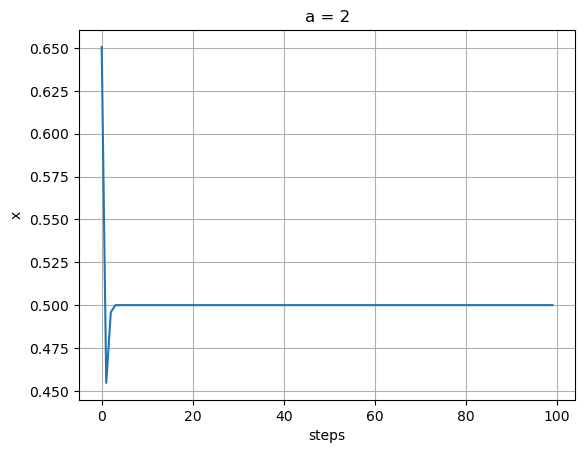

In [10]:
draw_process_chart(X0, a=2, steps=100, process=process)

Неподвижные точки процесса:

    x = 0
    x = (a-1)/a

In [ ]:
def process(x, a):
    return a * x * (1 - x)

In [11]:
print_process(x0=X0, a=1.1, steps=10, process=process)

0.65065 ➔ 0.25004 ➔ 0.20627 ➔ 0.18009 ➔ 0.16243 ➔ 0.14965 ➔ 0.13998 ➔ 0.13242 ➔ 0.12638 ➔ 0.12145 ➔ 

Формулируем гипотезу: значение стабилизируется в неподвижной точке процесса. 

Проверим её на значения а = 3, a = 3.8:

0.65065 ➔ 0.68192 ➔ 0.65072 ➔ 0.68185 ➔ 0.65079 ➔ 0.68179 ➔ 0.65086 ➔ 0.68172 ➔ 0.65093 ➔ 0.68166 ➔ 0.651 ➔ 0.6816 ➔ 0.65107 ➔ 0.68154 ➔ 0.65113 ➔ 0.68148 ➔ 0.6512 ➔ 0.68142 ➔ 0.65126 ➔ 0.68136 ➔ 0.65133 ➔ 0.6813 ➔ 0.65139 ➔ 0.68124 ➔ 0.65145 ➔ 0.68118 ➔ 0.65152 ➔ 0.68113 ➔ 0.65158 ➔ 0.68107 ➔ 

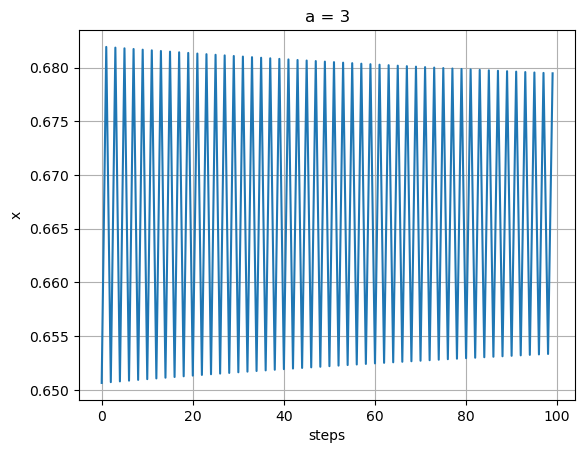

0.65065 ➔ 0.86376 ➔ 0.44718 ➔ 0.9394 ➔ 0.21633 ➔ 0.64423 ➔ 0.87095 ➔ 0.42709 ➔ 0.9298 ➔ 0.24803 ➔ 0.70874 ➔ 0.78443 ➔ 0.64258 ➔ 0.87275 ➔ 0.42203 ➔ 0.9269 ➔ 0.25748 ➔ 0.72649 ➔ 0.75507 ➔ 0.70277 ➔ 0.79376 ➔ 0.62209 ➔ 0.89336 ➔ 0.36202 ➔ 0.87765 ➔ 0.40804 ➔ 0.91786 ➔ 0.28648 ➔ 0.77676 ➔ 0.65893 ➔ 

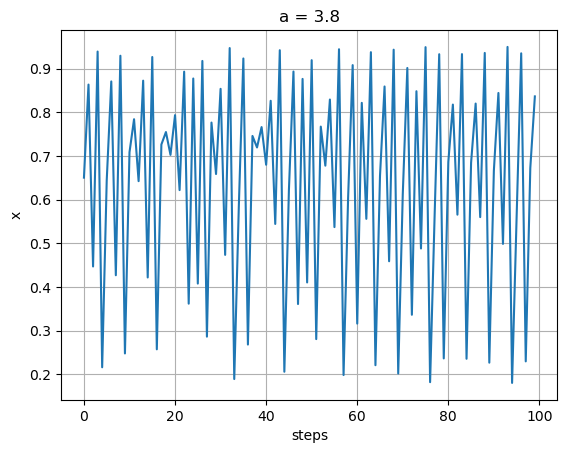

In [12]:
print_process(x0=X0, a=3, steps=30, process=process)

draw_process_chart(x0=X0, a=3, steps=100, process=process)

print_process(x0=X0, a=3.8, steps=30, process=process)
draw_process_chart(x0=X0, a=3.8, steps=100, process=process)

Как можно видеть, значение и не думает стабилизироваться. Гипотеза не верна!

Проверим, что будет происходить, если мы будем увеличивать а

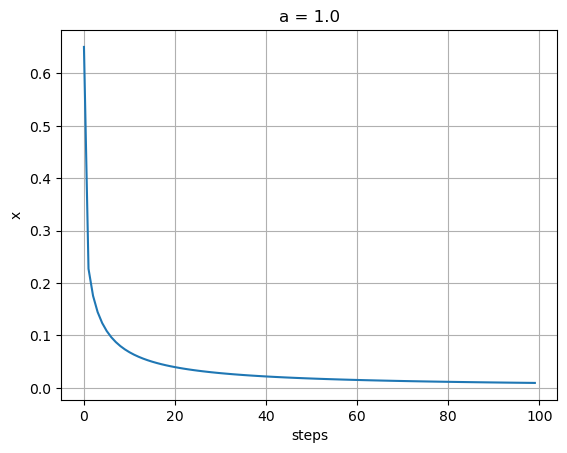

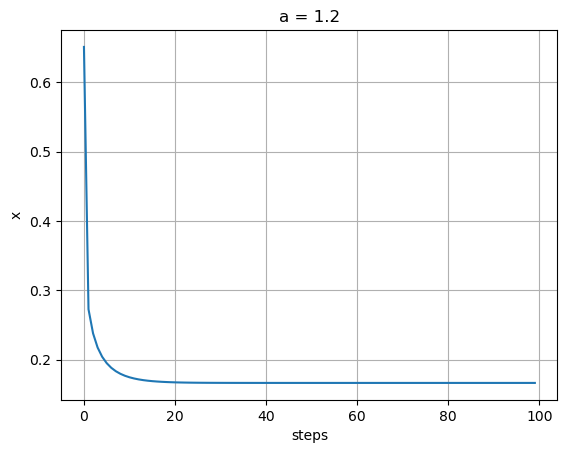

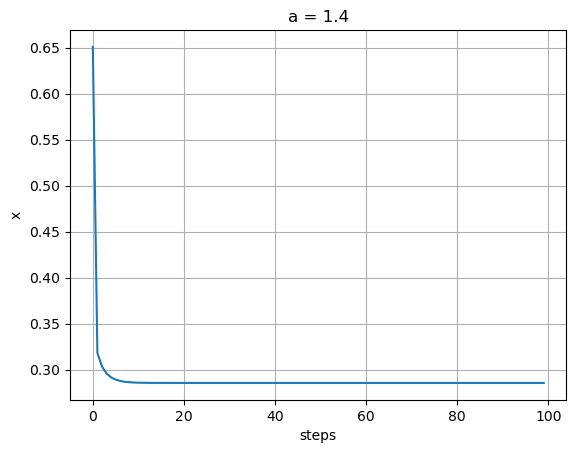

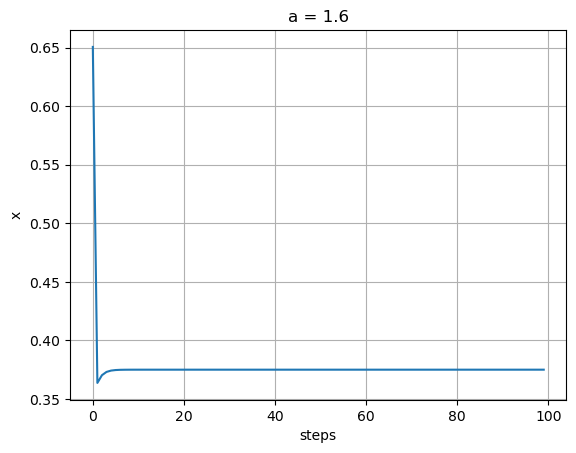

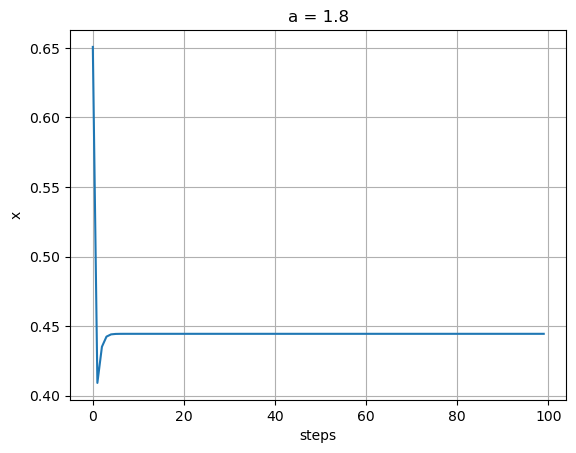

In [13]:
for a in np.arange(1, 2, 0.2):
    draw_process_chart(x0=X0, a=a, steps=100, process=process)

Пока всё идет хорошо. Значение стабилизируется в неподвижной точки процесса

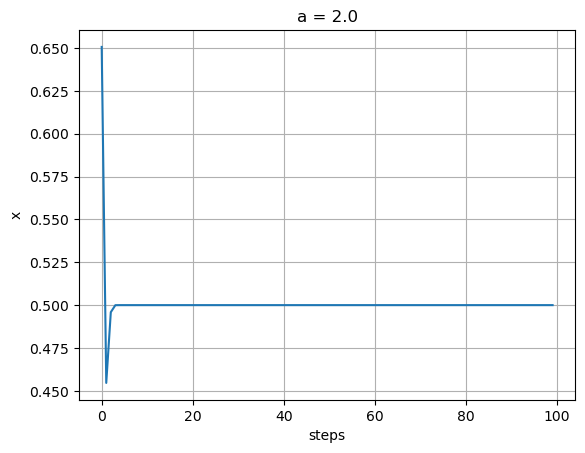

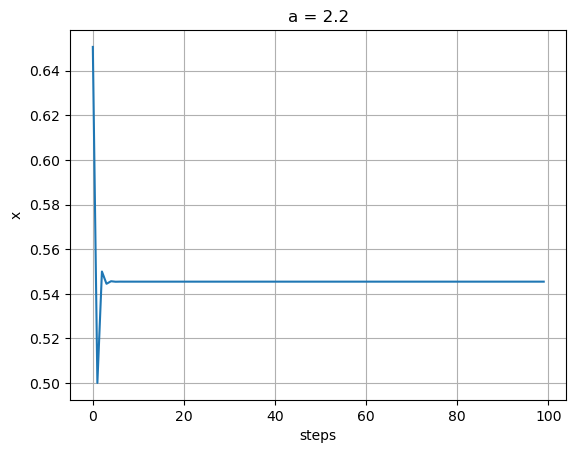

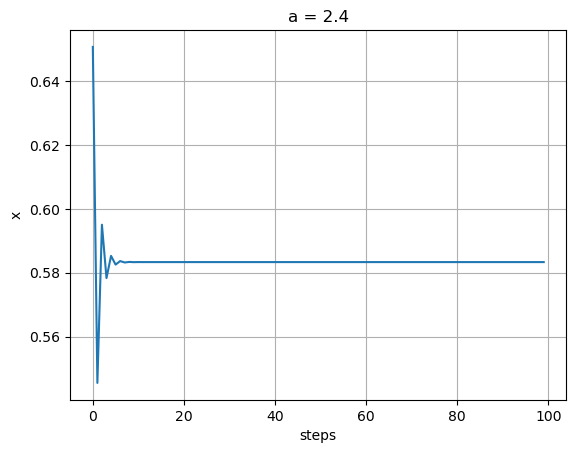

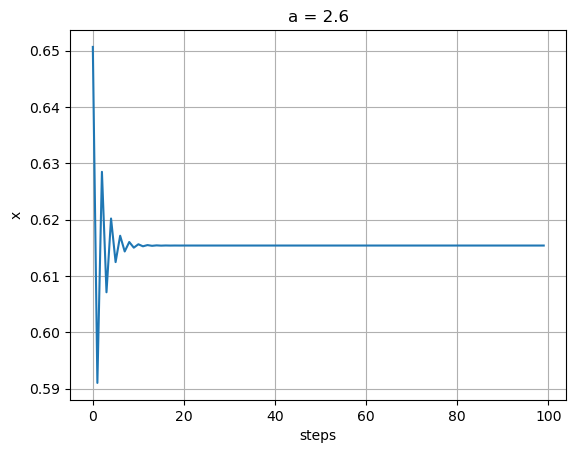

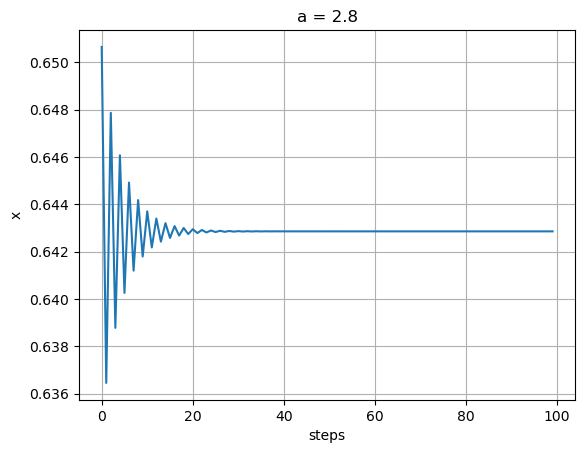

In [14]:
for a in np.arange(2, 2.9, 0.2):
    draw_process_chart(x0=X0, a=a, steps=100, process=process)

Мы видим, что возникает дрожание. Значение пытается стабилизироваться

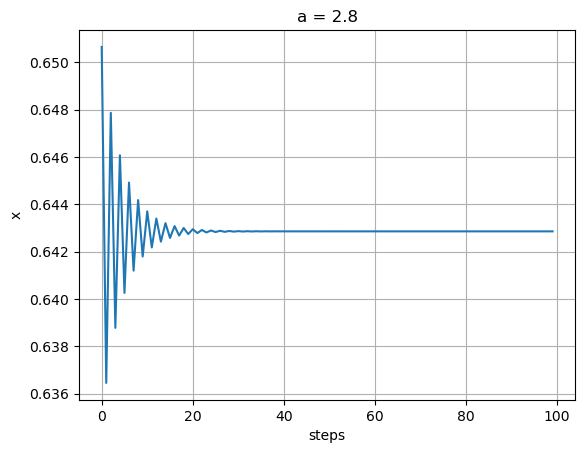

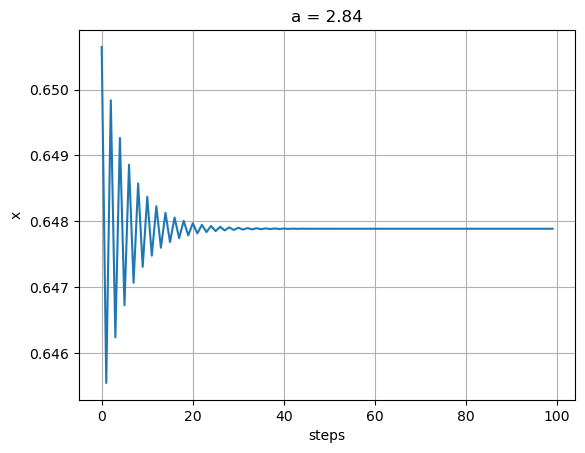

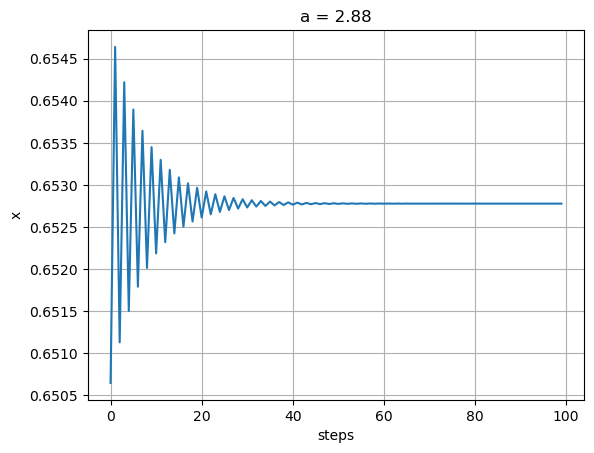

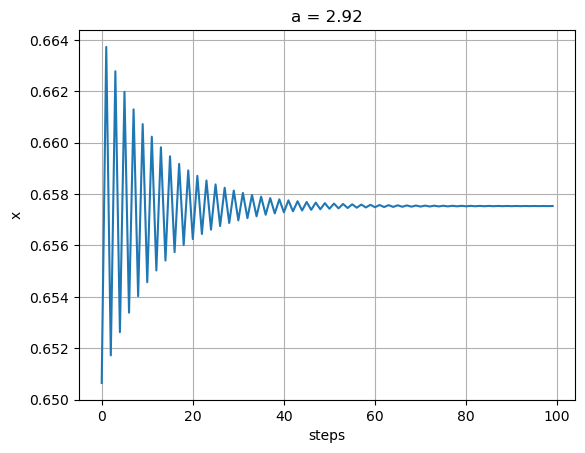

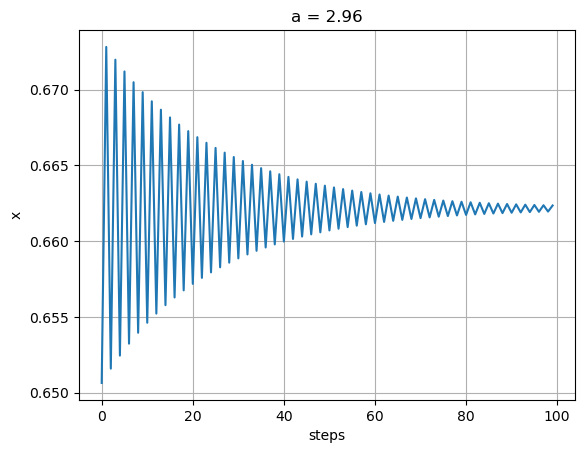

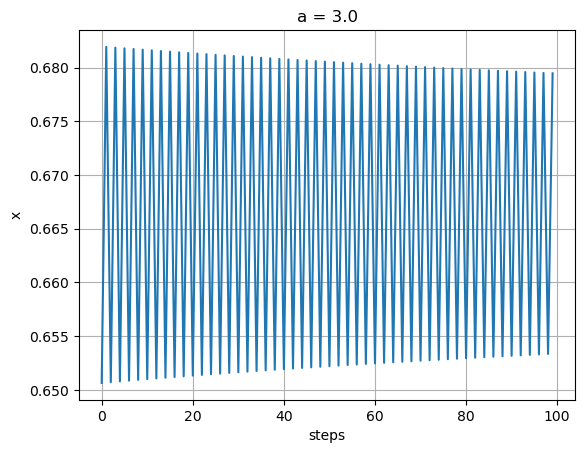

In [15]:
for a in np.arange(2.8, 3, 0.04):
    draw_process_chart(x0=X0, a=a, steps=100, process=process)

Постепенно способность стабилизироваться теряется

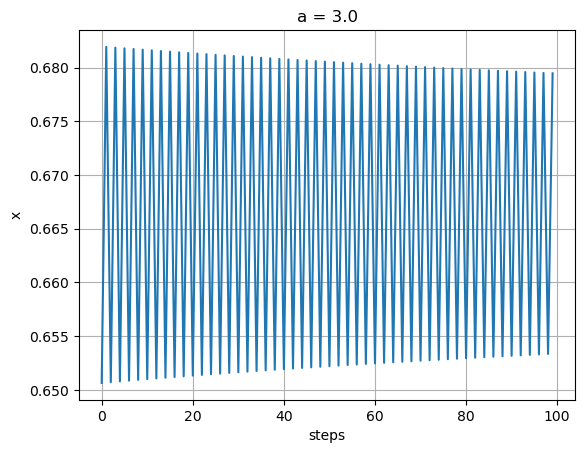

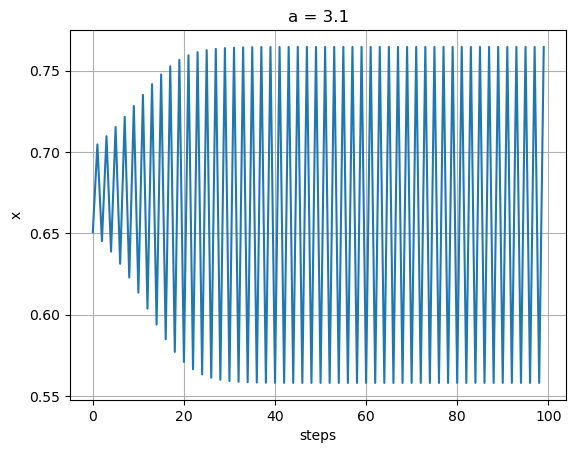

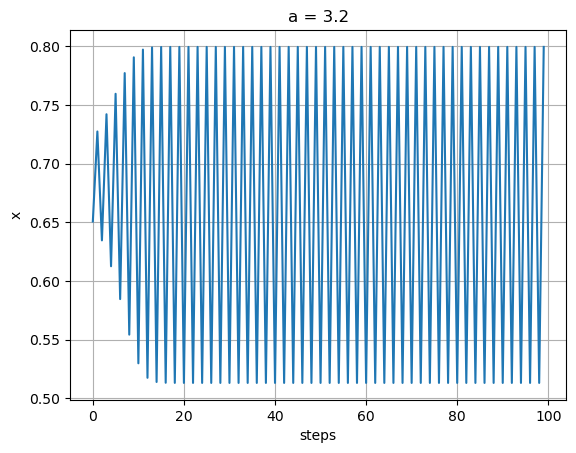

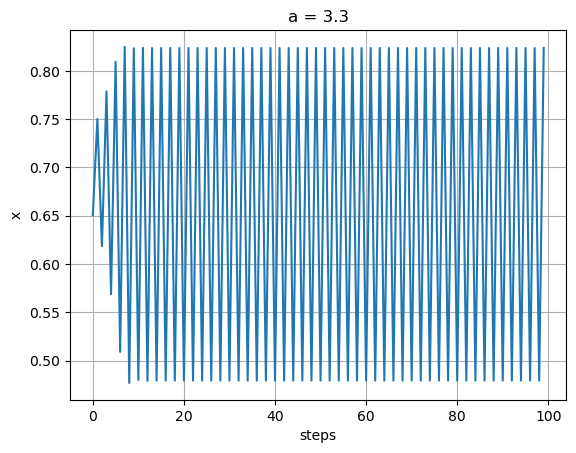

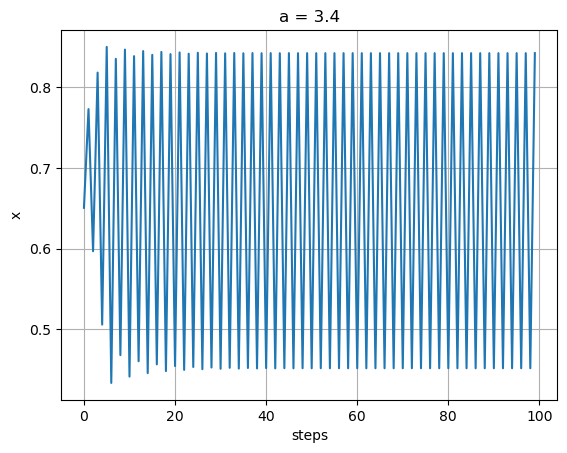

In [16]:
for a in np.arange(3, 3.5, 0.1):
    draw_process_chart(x0=X0, a=a, steps=100, process=process)

Происходит странное - вместо того, что бы сойтись к определенному значению, процесс начинает "*гулять*" между двумя.

In [17]:
print_process(x0=X0, a=3.4, steps=100, process=process)

0.65065 ➔ 0.77284 ➔ 0.5969 ➔ 0.81807 ➔ 0.50602 ➔ 0.84988 ➔ 0.43379 ➔ 0.8351 ➔ 0.46822 ➔ 0.84657 ➔ 0.44164 ➔ 0.83842 ➔ 0.46061 ➔ 0.84472 ➔ 0.44596 ➔ 0.84007 ➔ 0.45679 ➔ 0.84365 ➔ 0.44847 ➔ 0.84097 ➔ 0.45471 ➔ 0.84303 ➔ 0.44993 ➔ 0.84148 ➔ 0.45354 ➔ 0.84266 ➔ 0.45079 ➔ 0.84176 ➔ 0.45287 ➔ 0.84245 ➔ 0.45128 ➔ 0.84193 ➔ 0.45249 ➔ 0.84232 ➔ 0.45157 ➔ 0.84202 ➔ 0.45226 ➔ 0.84225 ➔ 0.45174 ➔ 0.84208 ➔ 0.45214 ➔ 0.84221 ➔ 0.45183 ➔ 0.84211 ➔ 0.45206 ➔ 0.84219 ➔ 0.45189 ➔ 0.84213 ➔ 0.45202 ➔ 0.84217 ➔ 0.45192 ➔ 0.84214 ➔ 0.452 ➔ 0.84217 ➔ 0.45194 ➔ 0.84215 ➔ 0.45198 ➔ 0.84216 ➔ 0.45195 ➔ 0.84215 ➔ 0.45197 ➔ 0.84216 ➔ 0.45195 ➔ 0.84215 ➔ 0.45197 ➔ 0.84216 ➔ 0.45196 ➔ 0.84215 ➔ 0.45197 ➔ 0.84216 ➔ 0.45196 ➔ 0.84215 ➔ 0.45197 ➔ 0.84216 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 

Участок от 3.4 до 4 мы будем исследовать с меньшим шагом между a

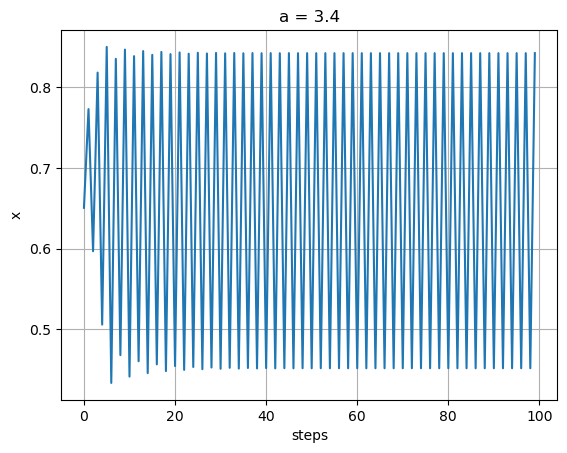

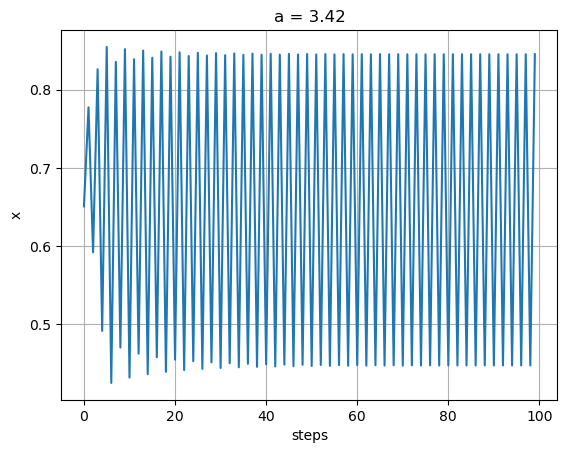

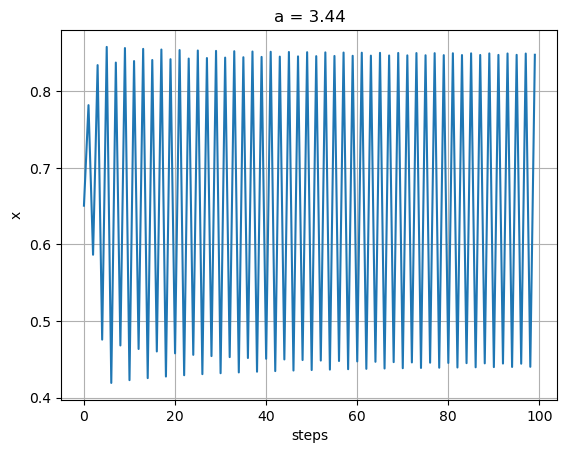

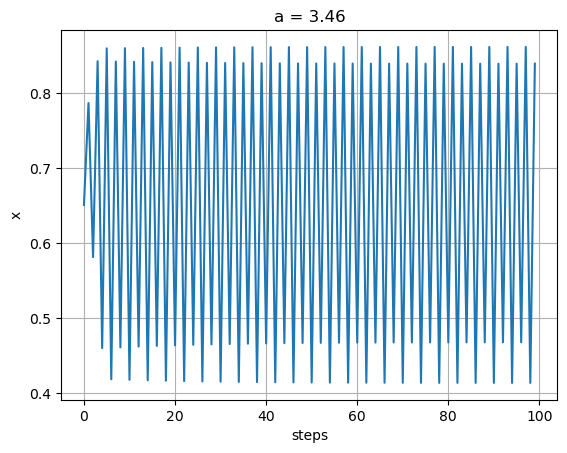

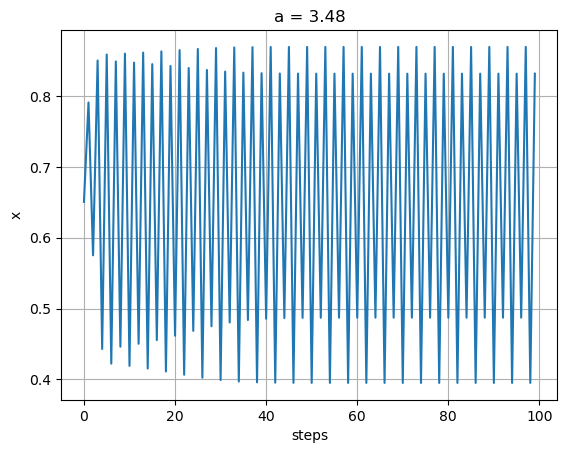

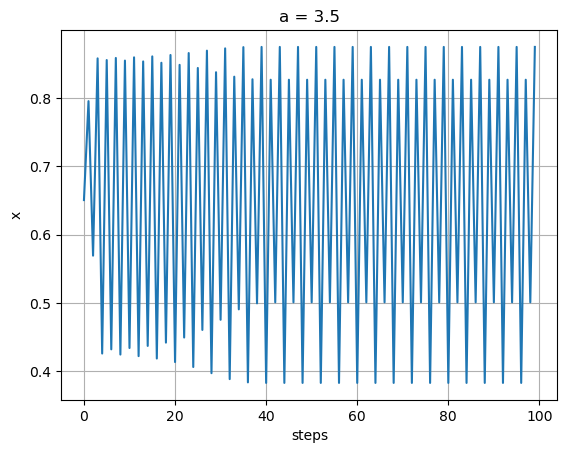

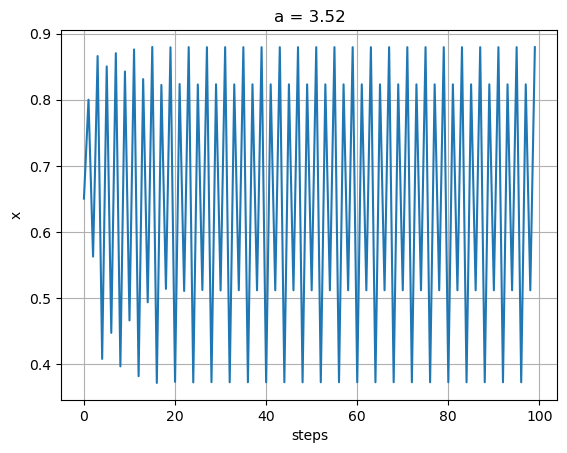

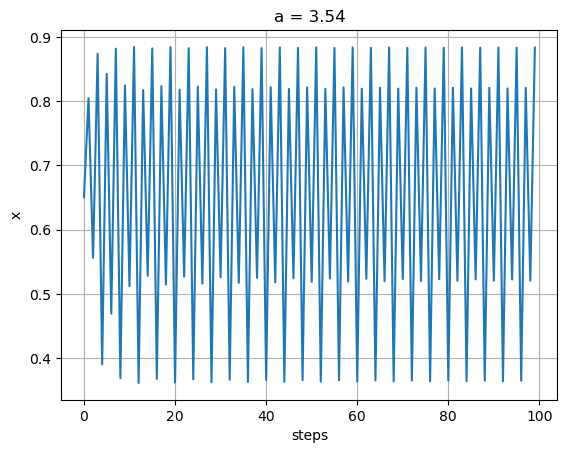

In [18]:
for a in np.arange(3.4, 3.54, 0.02):
    draw_process_chart(x0=X0, a=a, steps=100, process=process)

Наш процесс опять раздвоило. Теперь он прыгает между 4 значениями.

Для дальнейшего исследования, мы будем моделировать *в два раза больше* лет, но рисовать на графике *каждый второй год*

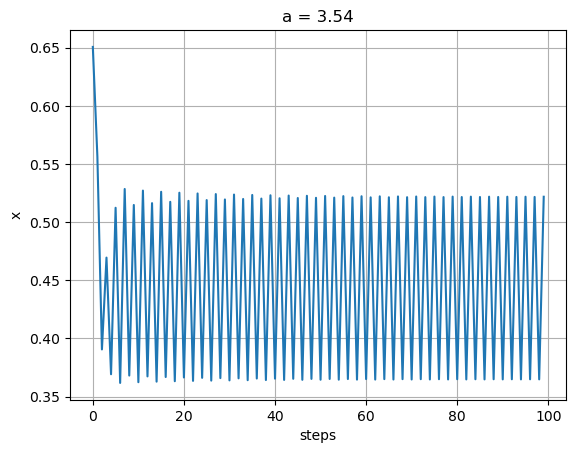

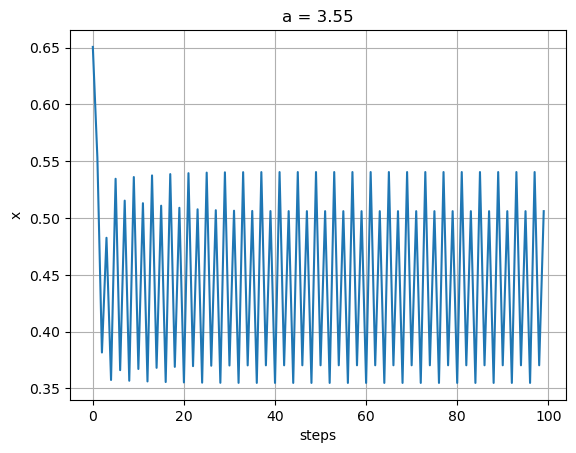

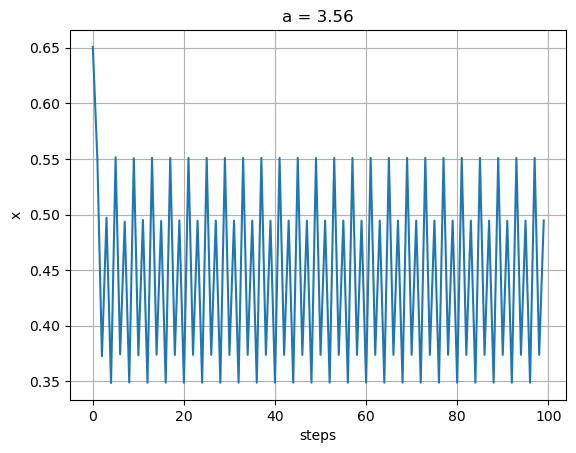

In [19]:
for a in np.arange(3.54, 3.56, 0.01):
    draw_process_chart(x0=X0, a=a, steps=200, process=process, every=2)

Как видно, значение *опять раздвоило*. Мы рисовали каждый второй год, а истинная картина при a=3.56 выглядит так:

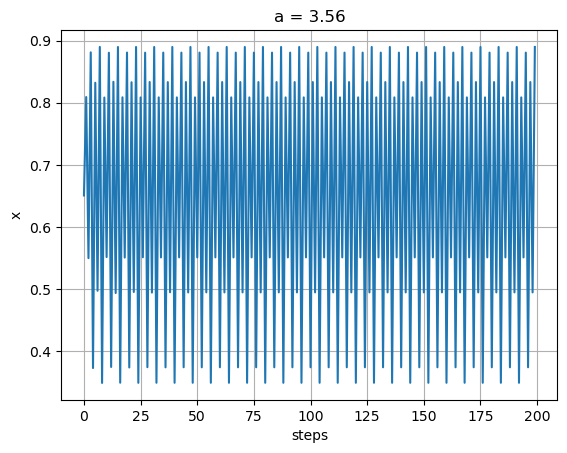

In [20]:
draw_process_chart(x0=X0, a=3.56, steps=200, process=process)

Будем рисовать каждый восьмой год:

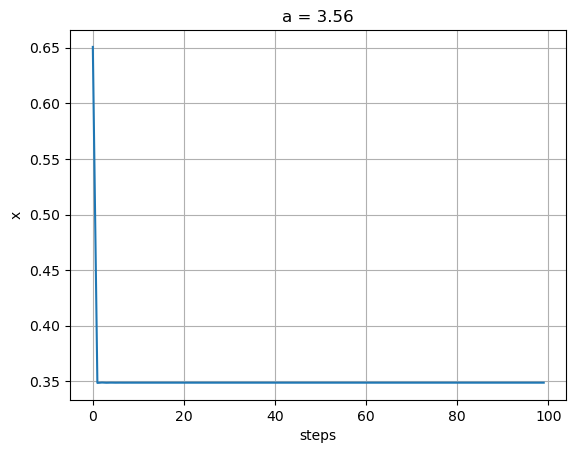

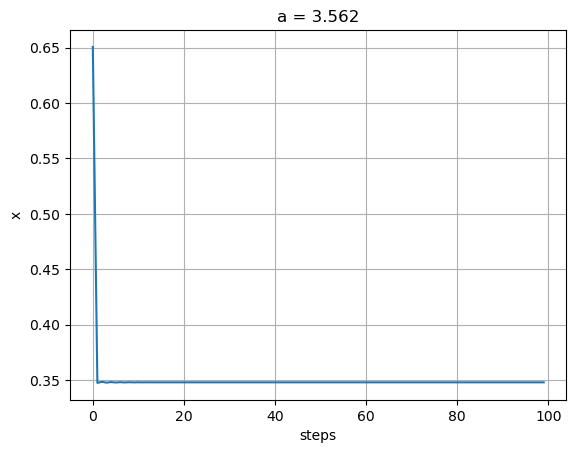

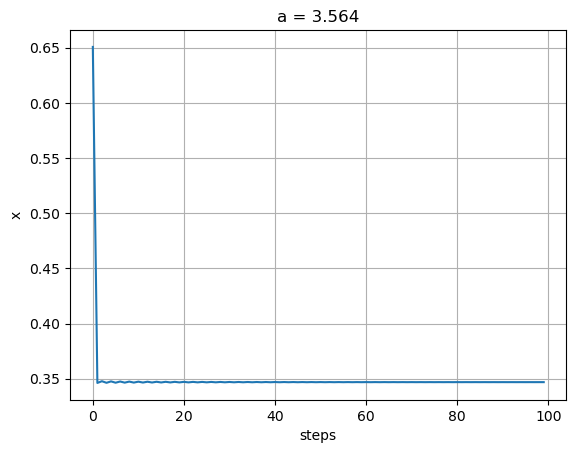

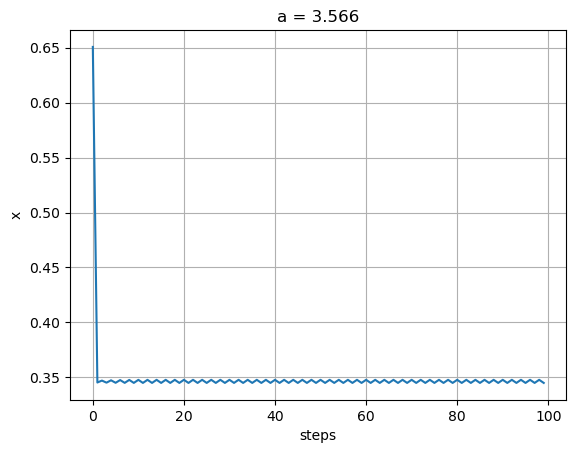

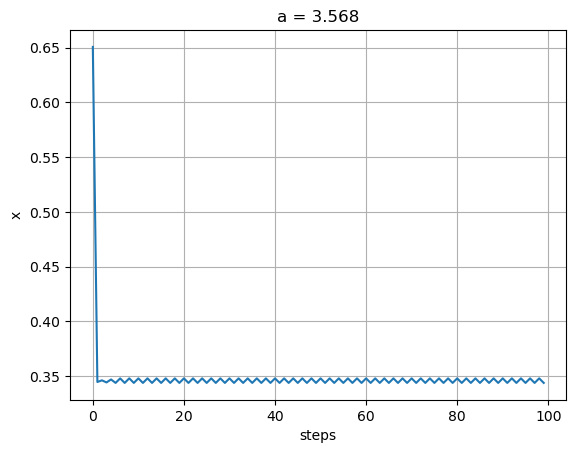

In [21]:
for a in np.arange(3.56, 3.57, 0.002):
    draw_process_chart(x0=X0, a=a, steps=800, process=process, every=8)

Можно видеть, как периоды удваивались ещё раз, затем ещё раз.

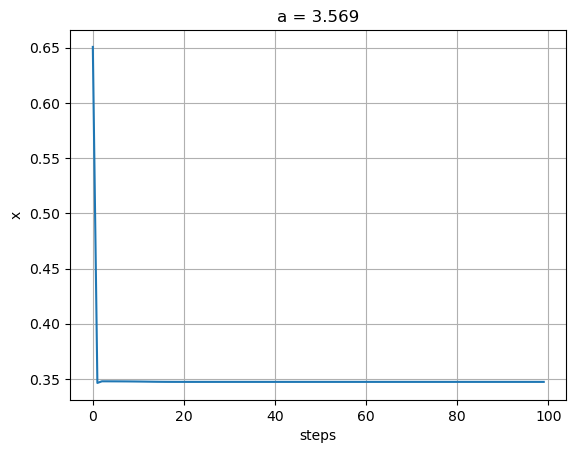

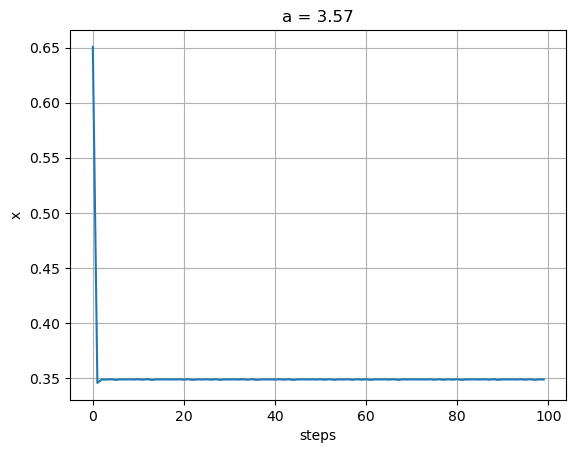

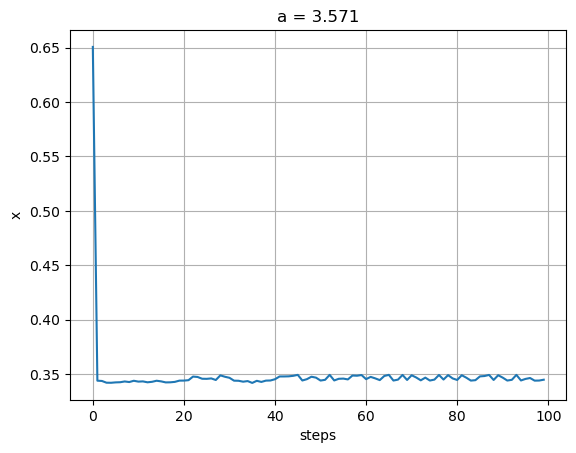

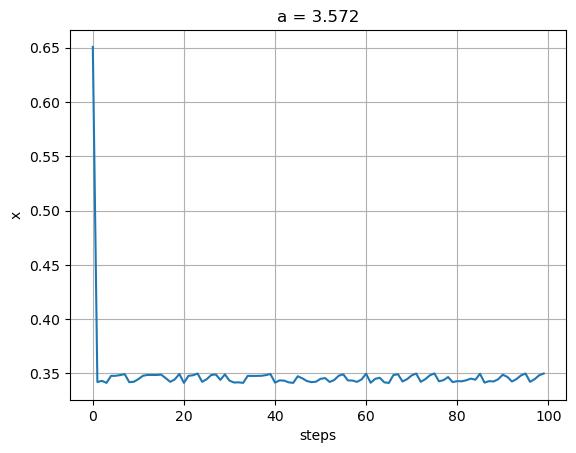

In [22]:
for a in np.arange(3.569, 3.572, 0.001):
    draw_process_chart(x0=X0, a=a, steps=3200, process=process, every=32)

Видно, что в какой-то момент последовательность начинает разбалтывать, и это уже сложно обьяснить удвоением периода. Рассмотрим каждый 64 элемент с мелким шагом до 3.59:

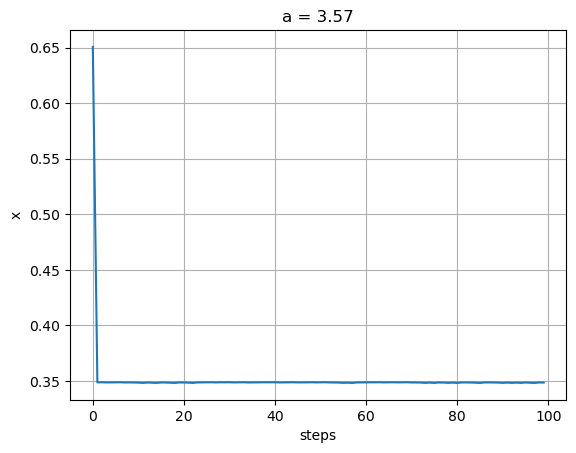

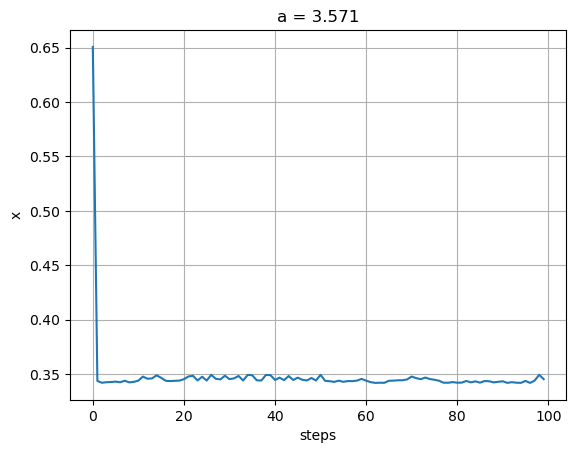

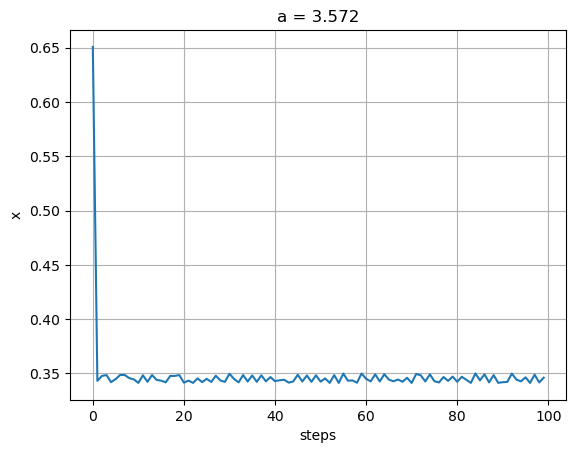

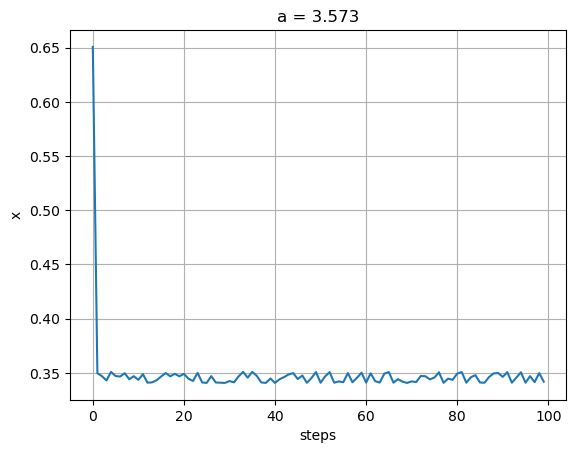

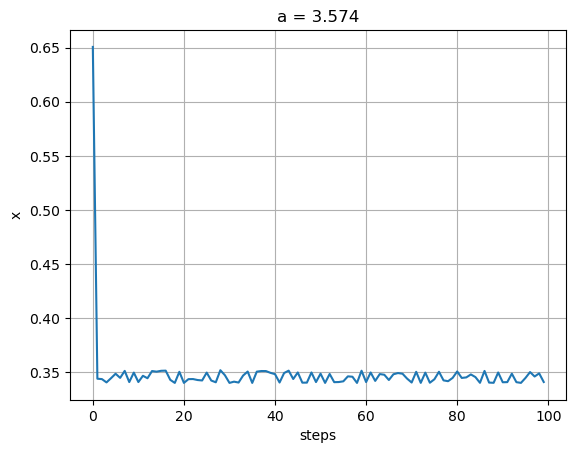

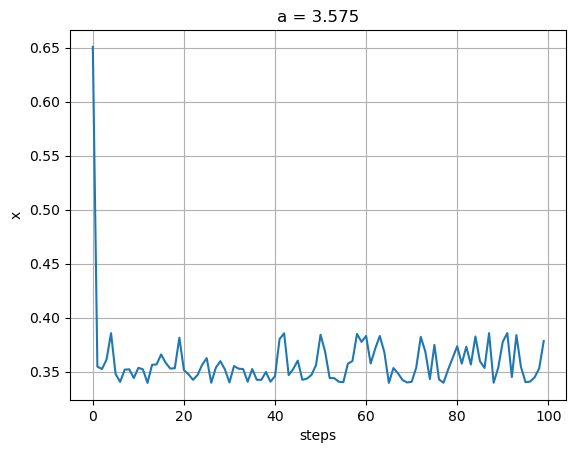

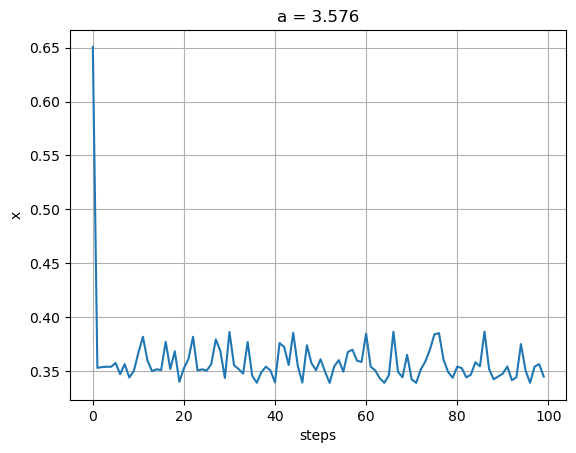

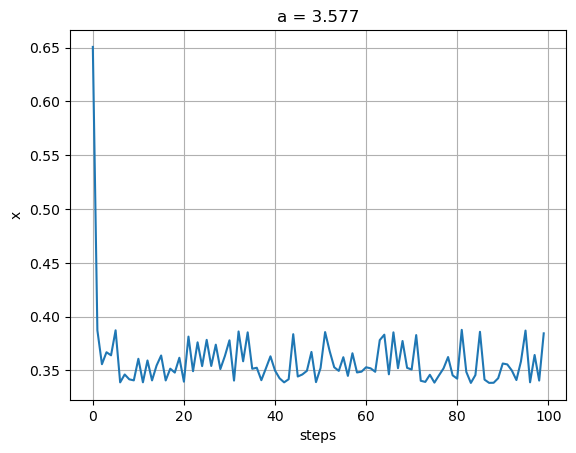

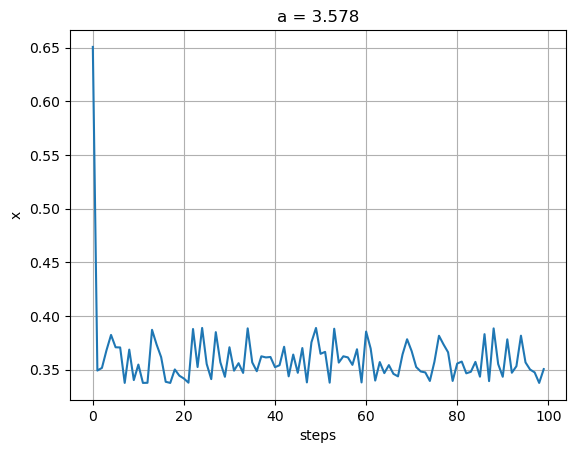

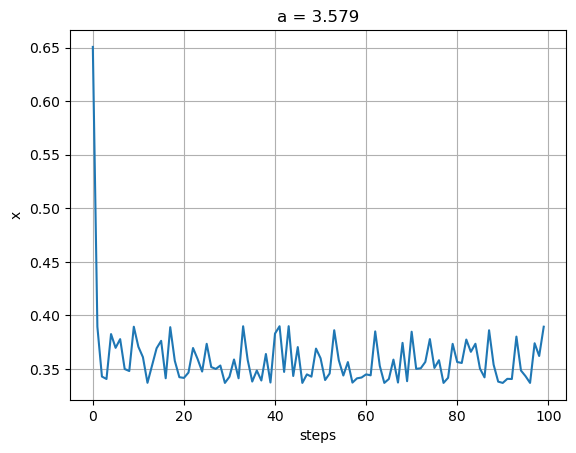

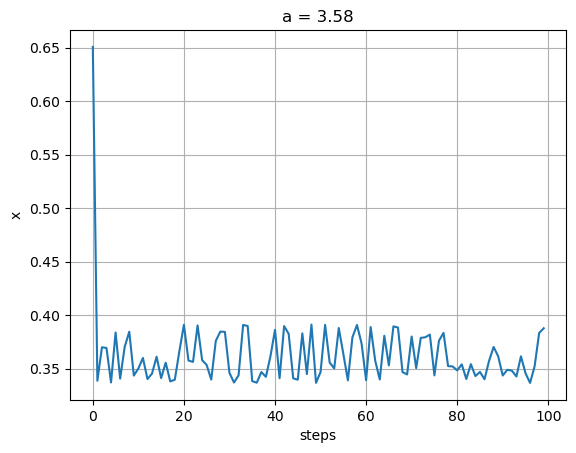

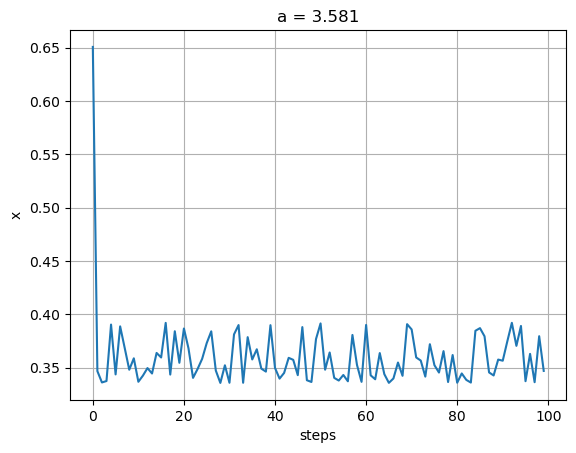

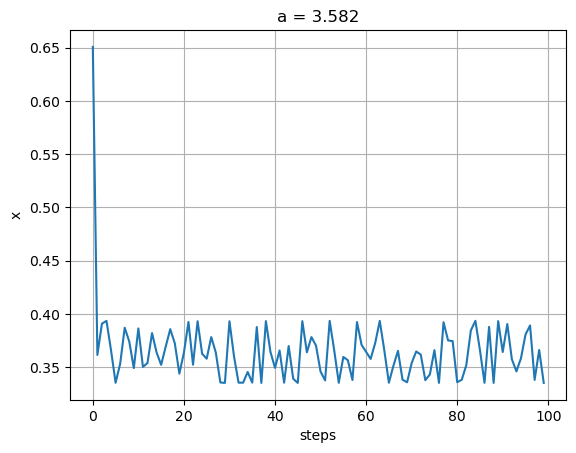

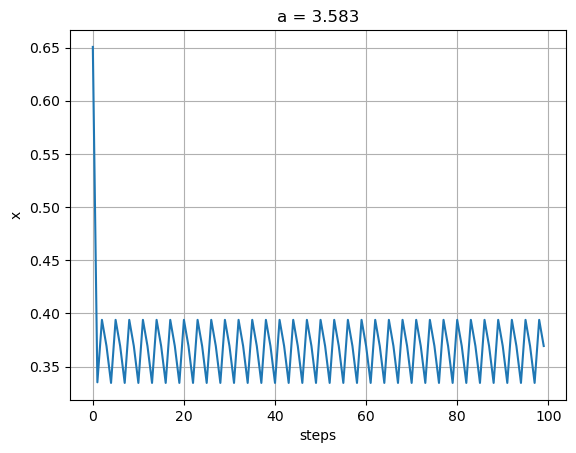

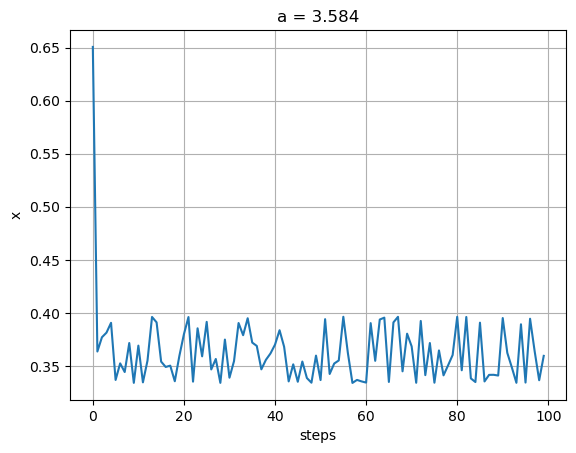

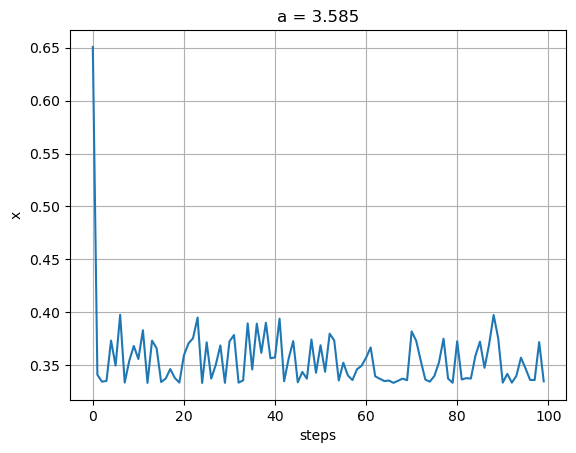

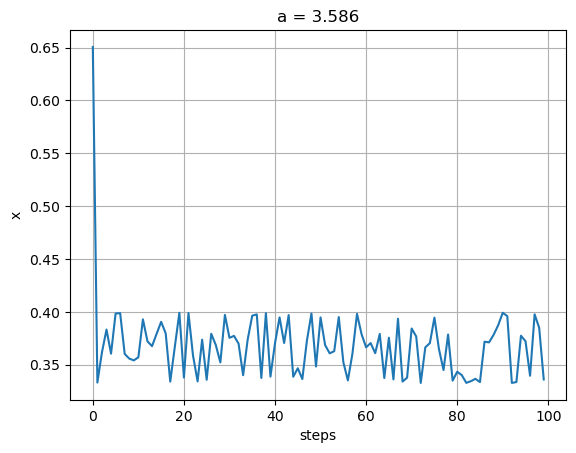

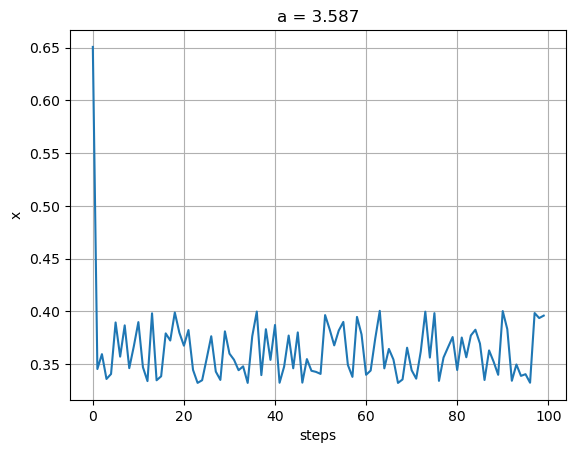

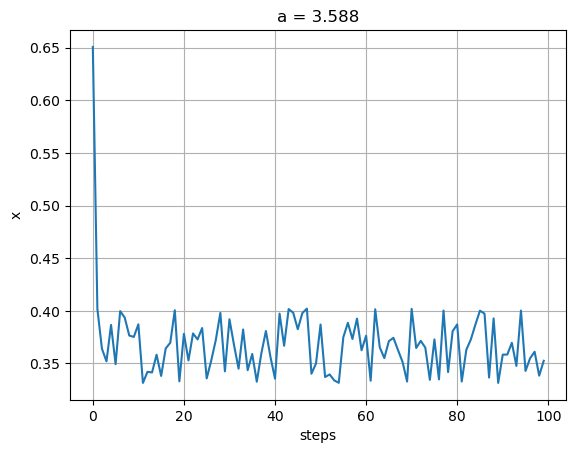

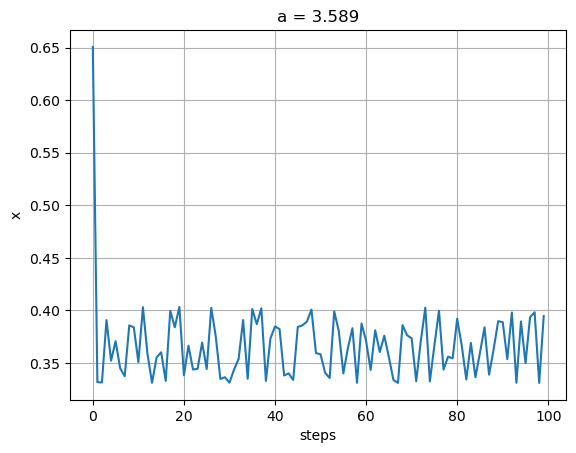

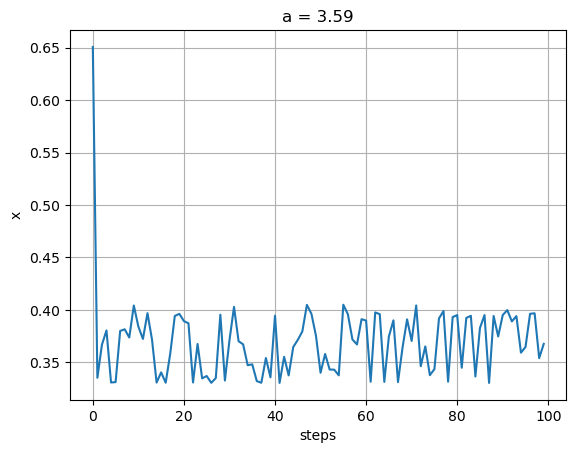

In [23]:
for a in np.arange(3.57, 3.59, 0.001):
    draw_process_chart(x0=X0, a=a, steps=6400, process=process, every=64)

Мы видим целую историю жизни процесса. Он стабилизируется, ловит период, после чего его разбалтывает. Опять ловит, и опять разбалтывает. Опять ловит..
При 3.5895 процесс чудом стабилизируется в одной позиции...

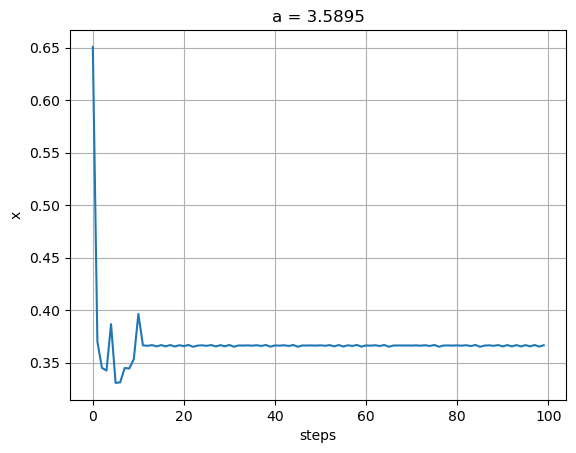

In [24]:
draw_process_chart(x0=X0, a=3.5895, steps=1600, process=process, every=16)

И его окончательно расколбашивает.

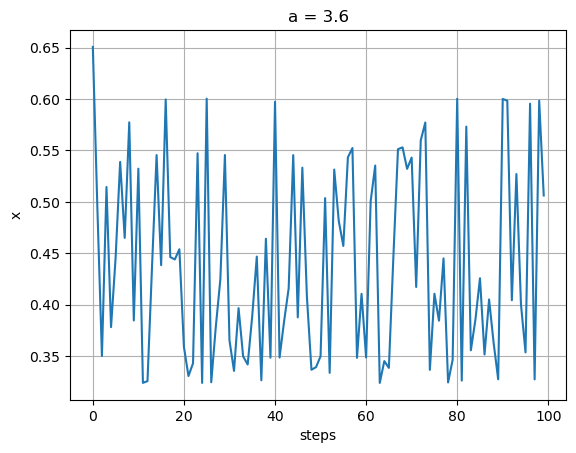

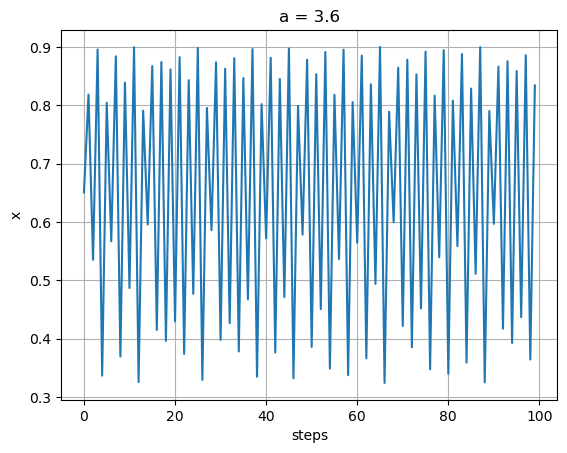

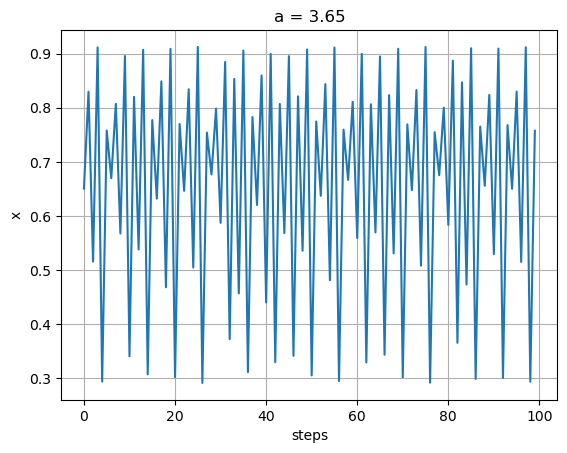

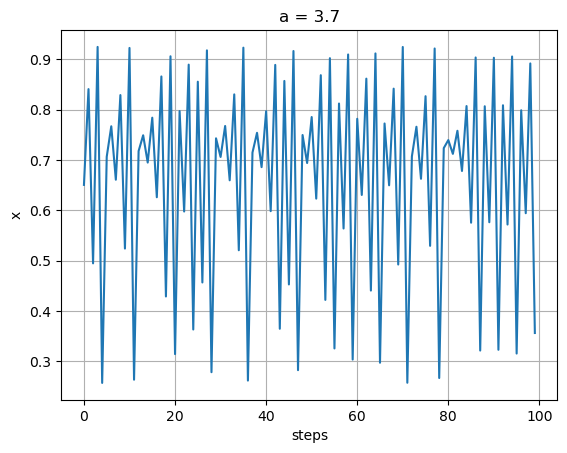

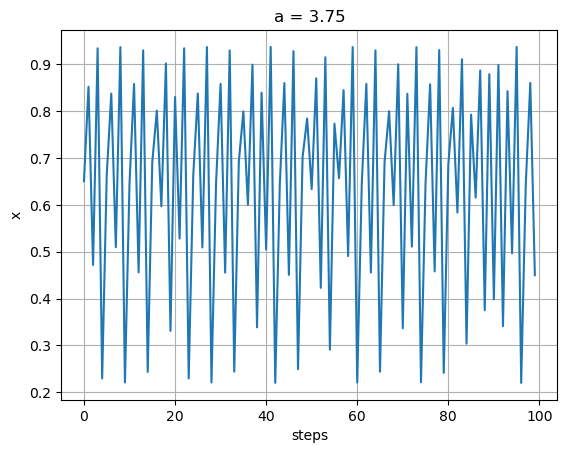

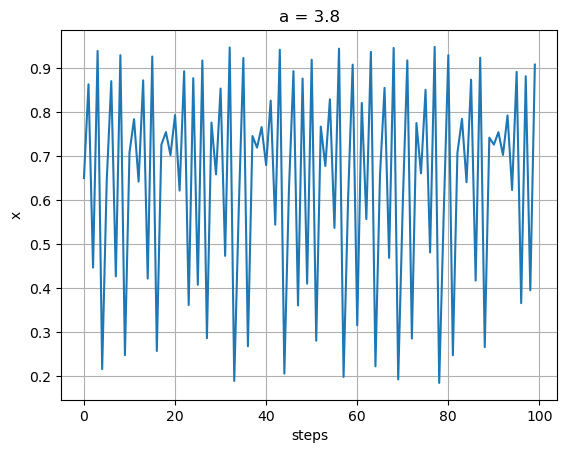

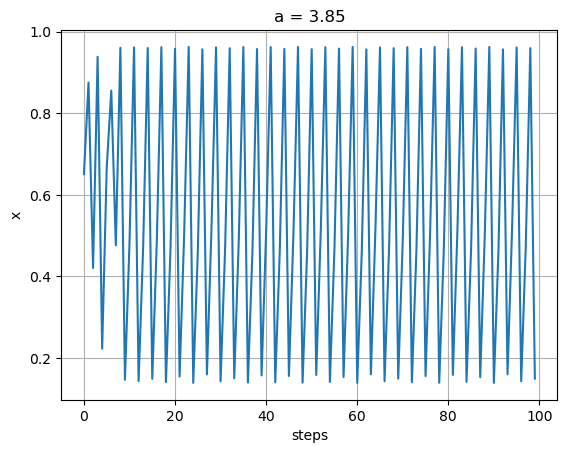

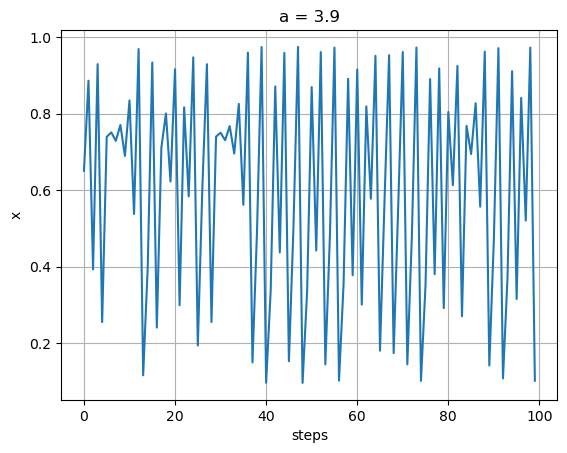

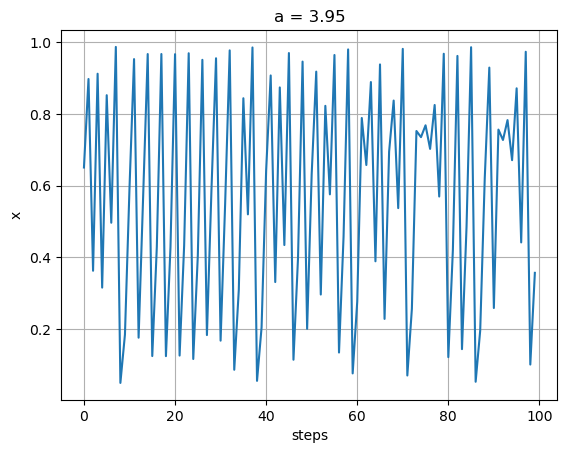

In [25]:
draw_process_chart(x0=X0, a=3.6, steps=6400, process=process, every=64)

for a in np.arange(3.6, 4, 0.05):
    draw_process_chart(x0=X0, a=a, steps=100, process=process)

А что будет после 4? Рассмотрим эволюцию процесса:

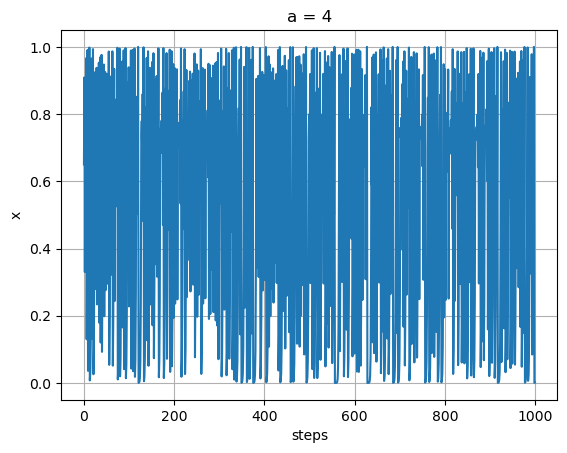

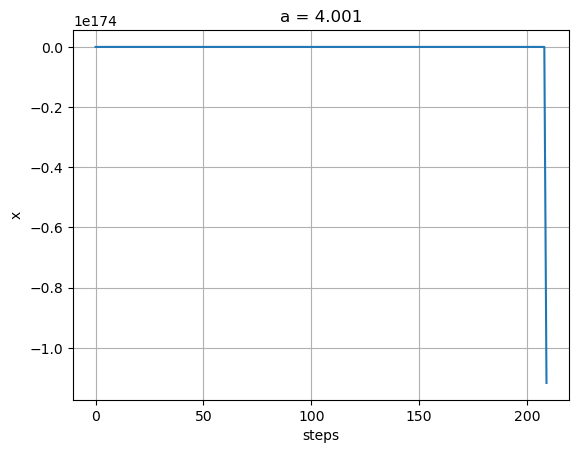

In [27]:
draw_process_chart(x0=X0, a=4, steps=1000, process=process)
draw_process_chart(x0=X0, a=4.001, steps=1000, process=process)

Как видно, процесс после 4 вылетает за разрешенный интервал [0,1] и дальше улетает в бесконечность.
(при некоторых x0 не улетает, вам может повезти)

**Промежуточный вывод:** Мы наблюдали "биографию" процесса от рождения до смерти. 
Теперь нужен более систематический подход для анализа этого поведения.

## Глава вторая. Орбитальное движение

Просмотр отдельных графиков дал нам интуицию, но теперь нужен инструмент для 
систематического анализа. Введем понятие *орбиты* - множества точек, к которым 
стремится процесс после переходного периода.

Введем функцию orbit(process, a, x0), вычисляющую *стабильную орбиту* процесса при разных значениях а. (при произвольном x0 от 0 до 1)

Орбитой называются те точки, рядом с которыми будут проходить значения функции по истечении достаточного для стабилизации числа шагов. Мы видили, что:

orbit(process, 2, 0.5) = {0.5}

orbit(process, 3.4, 0.5) = {0.84215, 0.45196} , так как там значения болтаются между двумя точками

а стабильной орбита для 3.8 вовсе не существует (как вариант, она включает бесконечное множество точек)

In [28]:
def orbit(process, a, x0):
    SKIP = 128
    STEPS = 128

    EPS = 0.001

    x = x0

    # пропускаем первые SKIP шага, что бы орбита стабилизировалась
    for _ in range(SKIP):
        x = process(x, a)
        if abs(x) > 1e10:
            break

    # Собираем следующие STEPS шагов для анализа 
    values = []

    for _ in range(STEPS):
        x = abs(process(x, a))
        values.append(x)
        if abs(x) > 1e10:
            break


    # Сортируем их и разбиваем на группы

    values.sort()
    
    groups = [[]]

    for x in values:
        group = groups[-1]
        if len(groups[-1]) == 0:
            group.append(x)
            continue

        prev = group[-1]
        if x - prev < EPS:
            group.append(x)
            continue

        groups.append([x])

    return [np.mean(group) for group in groups]    

In [29]:
for a in np.arange(2, 4, 0.1):
    o = orbit(process, a, 0.5)
    print(round(a,5), len(o), o)

2.0 1 [0.5]
2.1 1 [0.5238095238095238]
2.2 1 [0.5454545454545455]
2.3 1 [0.5652173913043478]
2.4 1 [0.5833333333333336]
2.5 1 [0.5999999999999999]
2.6 1 [0.6153846153846152]
2.7 1 [0.6296296296296298]
2.8 1 [0.642857142857143]
2.9 1 [0.6551724141384957]
3.0 2 [0.6494628632076138, 0.683057521702974]
3.1 2 [0.5580141252026952, 0.7645665199585948]
3.2 2 [0.5130445095326294, 0.7994554904673705]
3.3 2 [0.47942701982423375, 0.8236032832060693]
3.4 2 [0.451963247622239, 0.842154399434353]
3.5 4 [0.38281968301732344, 0.5008842103072184, 0.8269407065914385, 0.8749972636024644]
3.6 87 [0.3244166643157713, 0.32733086175066867, 0.3287180258370148, 0.33023309667560435, 0.33329811612828014, 0.3377282431723987, 0.3414301599495897, 0.347200767886762, 0.34885829759722964, 0.3536975231166125, 0.35640909022832085, 0.3666281672189433, 0.37319650158781187, 0.37708451571590074, 0.3824654779711392, 0.38564323568111725, 0.3881806612363504, 0.39370280005367475, 0.3961700319826205, 0.3976001913774423, 0.4015173

Эта функция работает, но анализировать множество чисел неудобно. 
Давайте визуализируем поведение орбит для всего диапазона параметра *a* одновременно.

Нарисуем *диаграмму орбит* - двумерный график, где по горизонтали откладывается 
параметр a, а по вертикали - все точки орбиты для этого параметра.

In [30]:
def draw_orbit_chart(a_range, x0, process):
    values_count = 1000
    a_values = np.linspace(*a_range, values_count)

    As = []
    Xs = []

    for a in a_values:
        for x in orbit(process, a, x0):
            
            As.append(a)
            Xs.append(x)

    fig, ax = plt.subplots()
    
    ax.plot(As, Xs, 'b,')

    ax.set_xlabel('a')
    ax.set_ylabel('x')

    plt.show()    

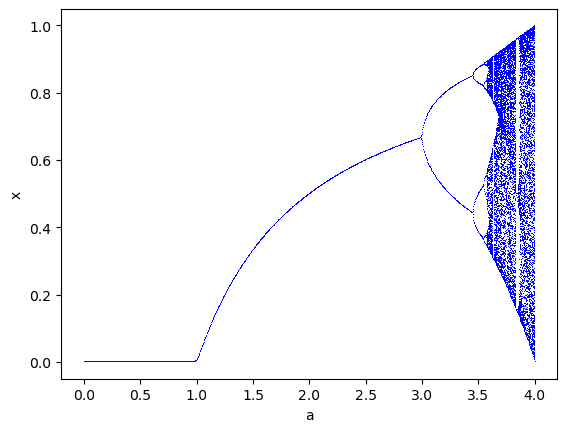

In [31]:
draw_orbit_chart([0,4], 0.5, process)

Вот она - **диаграмма биффуркаций Фейгенбаума**! Один из самых знаменитых образов 
в теории хаоса. На одном графике видна вся "история жизни" нашего процесса.

Давайте разберем её подробнее, исследуя отдельные участки.

Напомним, что наш процесс: x → a · x · (1 - x)

Можно выделить несколько характерных областей поведения:

* При а от 0 до 1 процесс сходится к 0. 
* При а от 1 и почти до 3 процесс сходится к ненулевому корню уравнения x = a * x * (1 - x). 

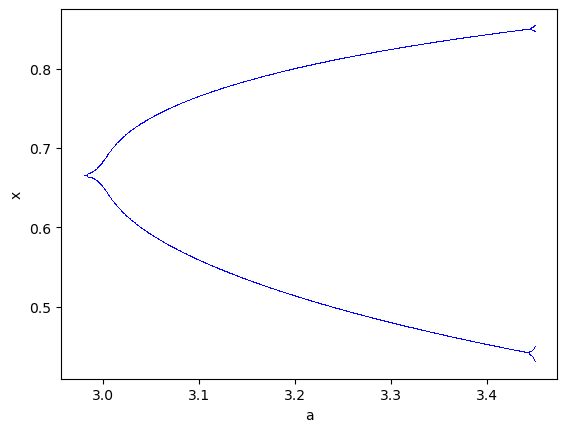

In [32]:
draw_orbit_chart([2.98,3.45], 0.5,process)

* Начиная примерно с 2.98 и до примерно 3.45 процесс сходится к *двум* значениям.

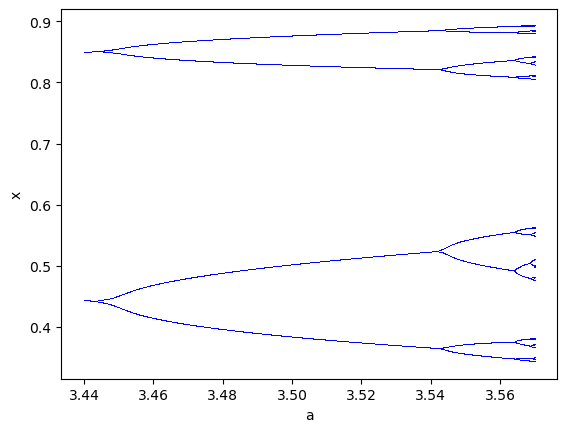

In [33]:
draw_orbit_chart([3.44,3.57], 0.5,process)

" * Начиная с 3.45, орбита постоянно раздваивается (2 → 4 → 8 → 16...), пока около 3.57 последовательность биффуркаций не сходится. После этого начинается хаотическое поведение!

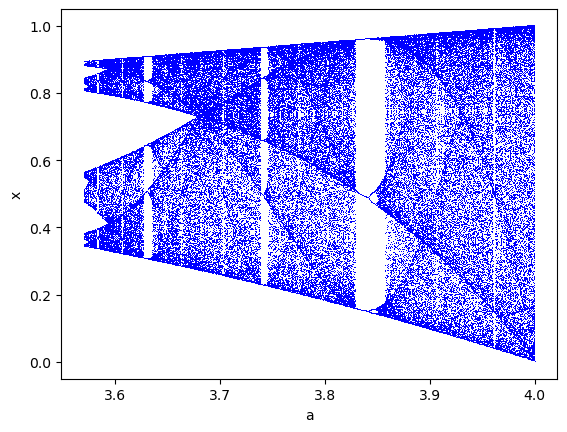

In [34]:
draw_orbit_chart([3.57,4], 0.5,process)

Мы можем наблюдать в некоторых диапазонах среди хаоса некие островки порядка. Самый крупный из их находится примерно в 3.828 - 3.858 и имеет длину орбиты 3. Внутри него тоже происходят удвоения периодов, причем каждая из трех ветвей в районе 3.85 погружается в свой собственный хаос.

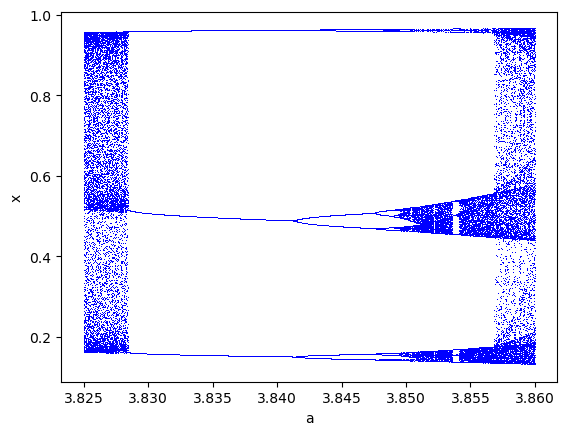

In [35]:
draw_orbit_chart([3.825,3.86], 0.5,process)

**Терминология:**
- Удвоение периода орбиты называется *биффуркацией*
- Бесконечная сходящаяся серия удвоений - *каскадом биффуркаций*
- Область хаотического поведения - *хаосом* или *странным аттрактором*

Вернемся к первому каскаду биффуркаций процесса:

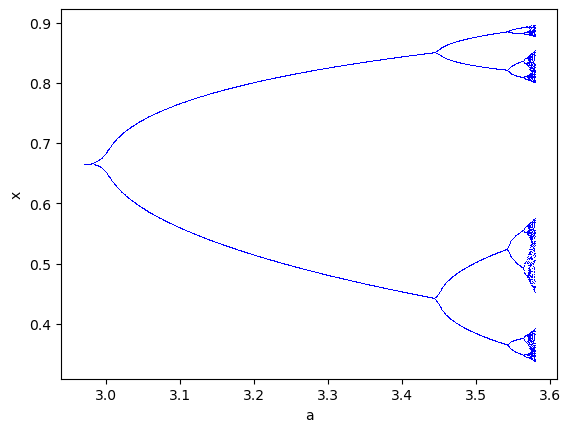

In [36]:
draw_orbit_chart([2.97,3.58], 0.5,process)

Зададим приблизительно точки биффуркаций

In [37]:
biffurcation = [
    3,
    3.44, 
    3.541, 
    3.564, 
    3.568, 
    3.57,
]

Удостоверимся, что это они

In [ ]:
p = 2
for b in biffurcation:
    draw_orbit_chart([p, b], 0.5,process)
    p = b

Рассмотрим точки последовательных биффуркаций:
- a₁ = 3.000 (первая биффуркация: 1 → 2)
- a₂ = 3.440 (вторая биффуркация: 2 → 4)  
- a₃ = 3.541 (третья биффуркация: 4 → 8)
- a₄ = 3.564 (четвертая: 8 → 16)
- a₅ = 3.568 (пятая: 16 → 32)
- a₆ ≈ 3.570 (шестая: 32 → 64)
- ...
- a∞ ≈ 3.5699456... (точка накопления)

Дистанция между соседними биффуркациями уменьшается в геометрической прогрессии. 

Основание этой прогрессии (вернее, обратное к нему), сходится к *первой константе Фейгенбаума*, равной 4.669201... 

А предел отношений между шириной ветвей - ко *второй константе Фейгенбаума*, равной 2.502907...

Природа этих констант и по сей день остается достаточно загадочной.

Удивительно, что эти константы *универсальны* - они появляются для всех 
одномерных отображений с одним максимумом, независимо от конкретного вида функции!

## Глава третяя. Широкий взгляд

Мы изучили поведение нашего процесса для вещественных значений параметра a.
Теперь сделаем смелый шаг: а что если рассмотреть *комплексные* значения параметра?

Это откроет нам совершенно новый взгляд на структуру устойчивости системы.

Когда современный математик видит некое загадочное явление, связанное с поведением функции, у него всегда есть соблазн посмотреть, что будет происходить, если в качестве аргументов функции подставить комлексные числа. Сделаем так и мы.

Будем исследовать устойчивость отображения x -> a * x * (1 - x) при разных (возможно, комплексных) а. 

Разделим все возможные (комплексные) а на два множества.

А именно: 
* если при неком а процесс имеет тенденцию убегать на бесконечность, поместим а в первое множество, 
* если при некотором а процесс имеет тенденцию оставаться в пределах единичного круга, поместим а во второе множество.

Нарисуем картинку, раскрасив первое множество черным цветом, а второе - белым

In [39]:
def draw_mandelbrots_chart(a_range, color):
    DPU = 600

    width  = a_range[0][1]-a_range[0][0]
    height = a_range[1][1]-a_range[1][0]

    if width < height:
        x_points, y_points = int(DPU*width/height), DPU
    else:
        x_points, y_points = DPU, int(DPU*height/width)

    xx = np.linspace(*a_range[0], x_points).reshape(1, -1)
    yy = np.linspace(*a_range[1], y_points)[::-1].reshape(-1, 1)
    zz = xx + 1j * yy
 
    zz = zz.ravel()

    calc_v = np.vectorize(color)

    image = calc_v(zz)

    image = np.reshape(image, (y_points, x_points))

    plt.xticks([0, x_points-1], [round(a_range[0][0],5), round(a_range[0][1],5)])
    plt.yticks([0, y_points-1], [round(a_range[1][1],5), round(a_range[1][0],5)])

    # cmap in ['viridis', 'plasma', 'inferno', 'magma', 'cividis']
    plt.imshow(image, cmap="inferno")
    plt.show()

Для этого нам потребуется функция раскраски, которую мы создадим из исходного процесса:

In [40]:
def color_bw(a):

    x0 = 0.5

    x = x0

    for _ in range(64):
        x = process(x, a)

        if abs(x) > 1:
            return 1

    return 0

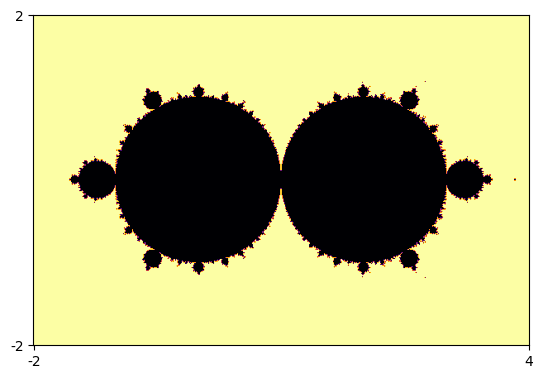

In [41]:
draw_mandelbrots_chart([[-2, 4], [-2, 2]], color_bw)

Что бы сделать картинку интереснее, можно раскрашивать белое множество дальше, в зависимости от того, на каком шаге произошел уход за разрешенный интервал. Так мы сделаем акцент на границе.

In [42]:
def color(a):

    x0 = 0.5

    x = x0

    for k in range(64):
        x = process(x, a)

        if abs(x) > 1:
            return 64-k

    return 0

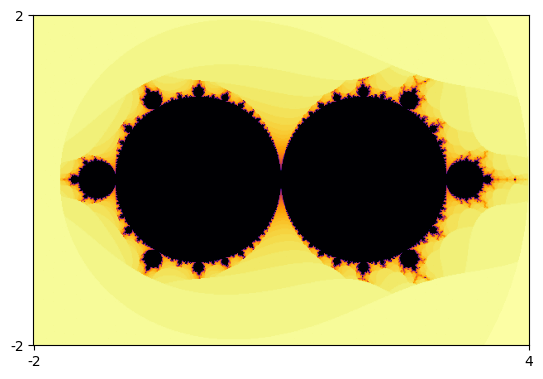

In [43]:
draw_mandelbrots_chart([[-2, 4], [-2, 2]], color)

Рассмотрим подробнее некоторые кусочки

In [44]:
biffurcation = [
    1,
    3,
    3.44,
    3.541, 
    3.564, 
]

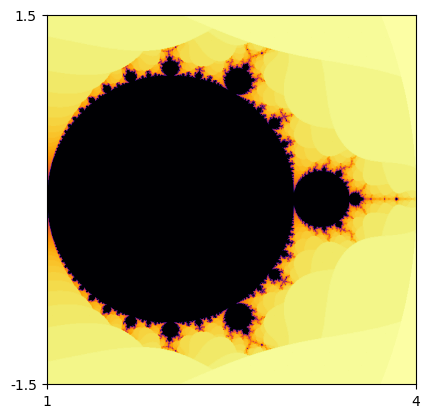

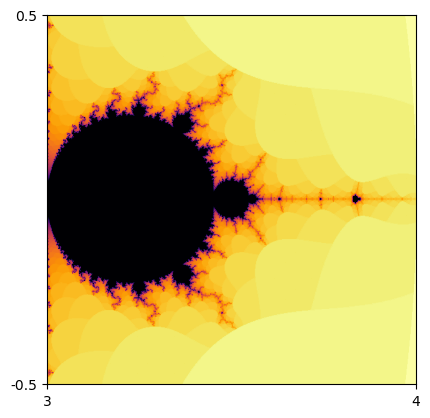

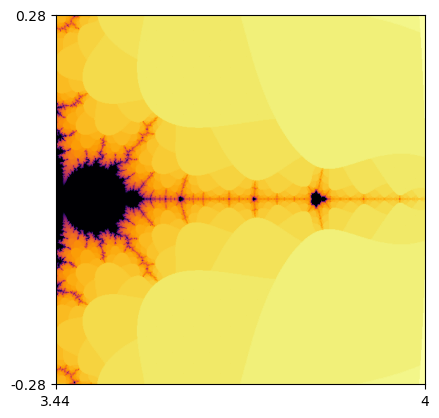

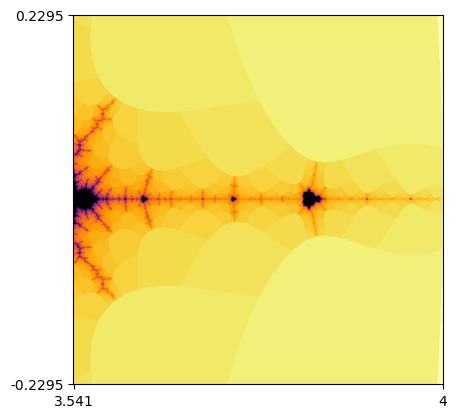

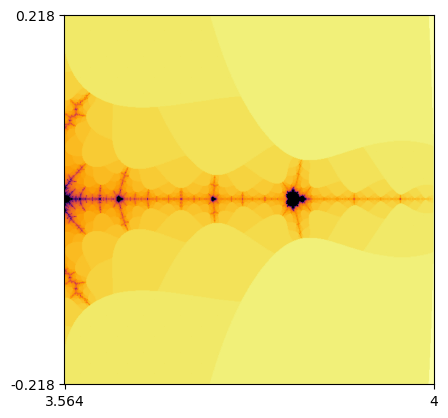

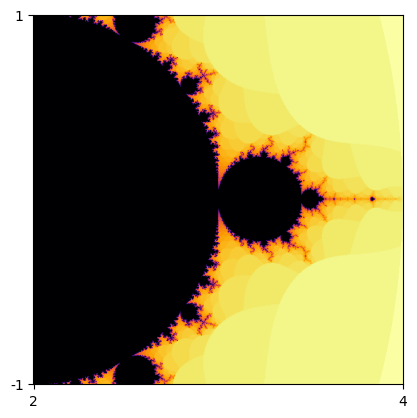

In [45]:
for b in biffurcation:
    draw_mandelbrots_chart([[b, 4], [-(4-b)/2, (4-b)/2]], color)

draw_mandelbrots_chart([[2, 4], [-1, 1]], color)

Сравним множество устойчивости с диаграммой орбит:

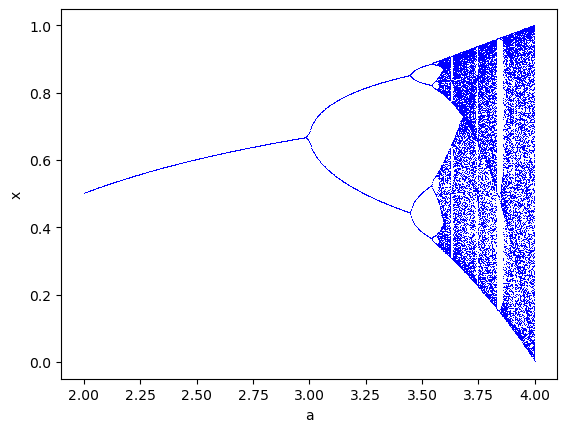

In [46]:
draw_orbit_chart([2,4], 0.5, process)

Обратите внимание: вещественная ось на комплексном изображении в точности 
соответствует диаграмме орбит! Комплексное расширение показывает, что 
структура устойчивости имеет фрактальную природу во всех направлениях.

## Глава четвертая. Универсальность хаоса

Удивительный факт: поведение, которое мы наблюдали для логистического отображения,
*универсально* для широкого класса нелинейных систем!

Константы Фейгенбаума и каскад биффуркаций появляются в любых гладких 
одномерных отображениях с одним максимумом. Продемонстрируем это на других функциях.

Рассмотрим ещё две функции: `x -> a*sin(pi*x)` и `x -> x^2 + a`

In [47]:
def process1(x, a):
    return x**2 + a

In [48]:
def color1(a):

    x0 = 0

    x = x0

    for k in range(64):
        x = process1(x, a)

        if abs(x) > 2:
            return k

    return 0

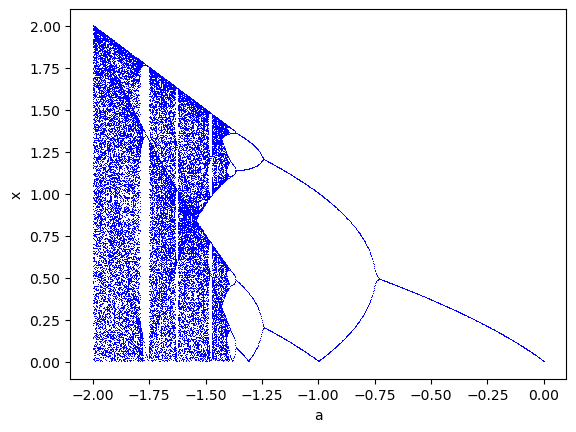

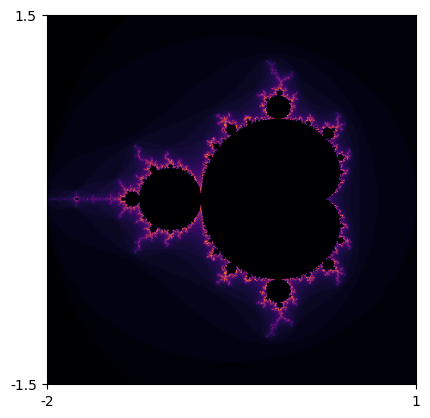

In [49]:
draw_orbit_chart([-2,0], 0, process1)

draw_mandelbrots_chart([[-2, 1], [-1.5, 1.5]], color1)

In [50]:
def process2(x, a):
    return a * np.sin(np.pi*x)

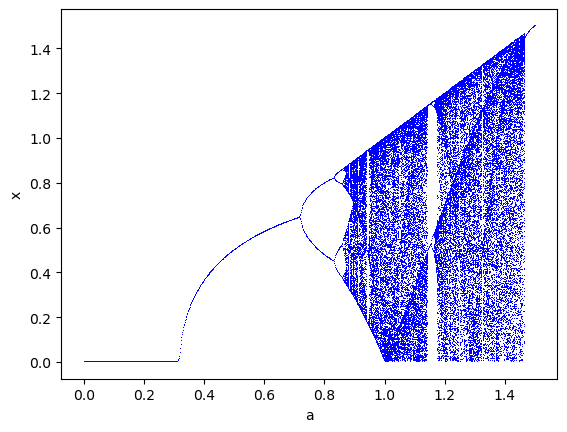

In [51]:
draw_orbit_chart([0,1.5], 0.5, process2)

In [52]:
def color2(a):

    x0 = 0.5

    x = x0

    for k in range(64):
        x = process2(x, a)

        if abs(x) > 10:
            return k

    return 64

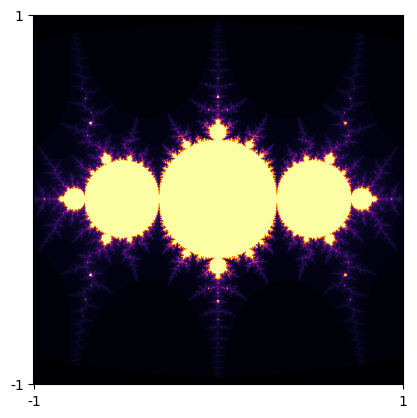

In [53]:
draw_mandelbrots_chart([[-1, 1], [-1, 1]], color2)

**Вывод:** Все три функции демонстрируют:
- Каскад биффуркаций
- Переход к хаосу через удвоение периода
- Фрактальную структуру границы устойчивости
- Окна периодичности в хаотической области

Это подтверждает **универсальность** открытых нами закономерностей!

## Глава пятая. Множество Джулиа

В третьей главе мы исследовали устойчивость при различных значениях параметра a.
Теперь перевернем вопрос: зафиксируем параметр a и исследуем, как влияет 
выбор *начального условия* на поведение системы.

Это приведет нас к понятию *множества Джулиа* - одному из самых красивых 
объектов в математике.

**Идея:** Вместо варьирования параметра a при фиксированном x₀, 
теперь зафиксируем параметр a и будем варьировать начальное условие x₀.

Для каждого процесса мы можем построить *множество Джулиа* - множество начальных точек в комплексной плоскости, 
при которых процесс остается ограниченным.

Граница этого множества имеет фрактальную структуру и демонстрирует самоподобие.

In [55]:
def draw_julia_set(a, x_range, y_range, max_iter=64, threshold=10):
    """
    Рисует множество Джулиа для процесса x -> a*x*(1-x) при фиксированном a
    
    Args:
        a: параметр процесса (может быть комплексным)
        x_range: диапазон [xmin, xmax] для реальной части
        y_range: диапазон [ymin, ymax] для мнимой части
        max_iter: максимальное число итераций
        threshold: порог ухода на бесконечность
    """
    DPU = 800
    
    width = x_range[1] - x_range[0]
    height = y_range[1] - y_range[0]
    
    if width < height:
        x_points, y_points = int(DPU * width / height), DPU
    else:
        x_points, y_points = DPU, int(DPU * height / width)
    
    xx = np.linspace(*x_range, x_points).reshape(1, -1)
    yy = np.linspace(*y_range, y_points)[::-1].reshape(-1, 1)
    z0 = xx + 1j * yy
    
    z = z0.copy()
    image = np.zeros(z.shape)
    
    for k in range(max_iter):
        # Применяем процесс
        z = a * z * (1 - z)
        
        # Находим точки, которые ушли на бесконечность
        mask = (np.abs(z) > threshold) & (image == 0)
        image[mask] = k
    
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.title(f'Множество Джулиа для a = {a}')
    
    ax.set_xlabel('Re(x)')
    ax.set_ylabel('Im(x)')
    
    # Используем цветовую схему для визуализации скорости ухода
    plt.imshow(image, extent=[x_range[0], x_range[1], y_range[0], y_range[1]], 
               cmap='hot', origin='lower')
    plt.colorbar(label='Итерации до ухода')
    plt.show()

Рассмотрим множество Джулиа для нескольких характерных значений параметра a:

### a = 2 (точка стабилизации) ###

/tmp/ipykernel_11479/1428469888.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
/tmp/ipykernel_11479/1428469888.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


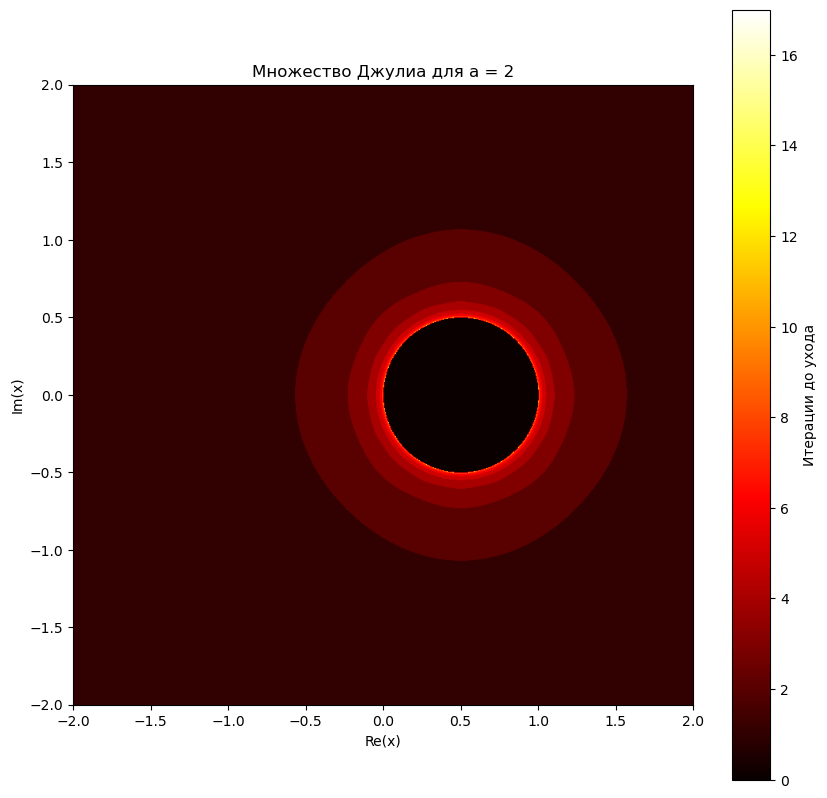

In [56]:
draw_julia_set(2, [-2, 2], [-2, 2])

### a = 3 (перед первой биффуркацией) ###

/tmp/ipykernel_11479/1428469888.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
/tmp/ipykernel_11479/1428469888.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


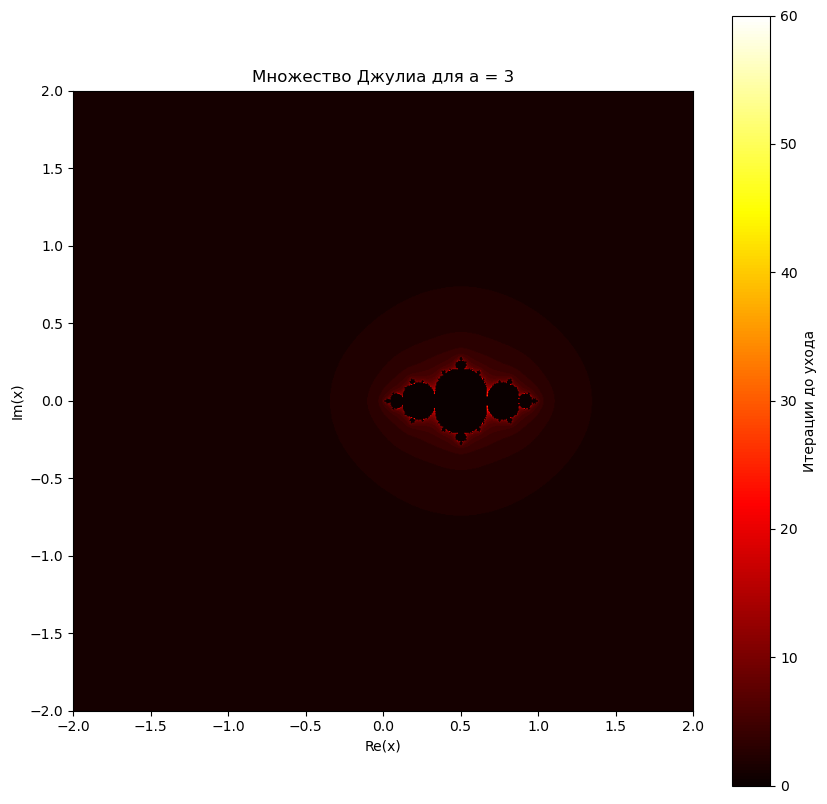

In [57]:
draw_julia_set(3, [-2, 2], [-2, 2])

### a = 3.5 (в области удвоения периода) ###

/tmp/ipykernel_11479/1428469888.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
/tmp/ipykernel_11479/1428469888.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


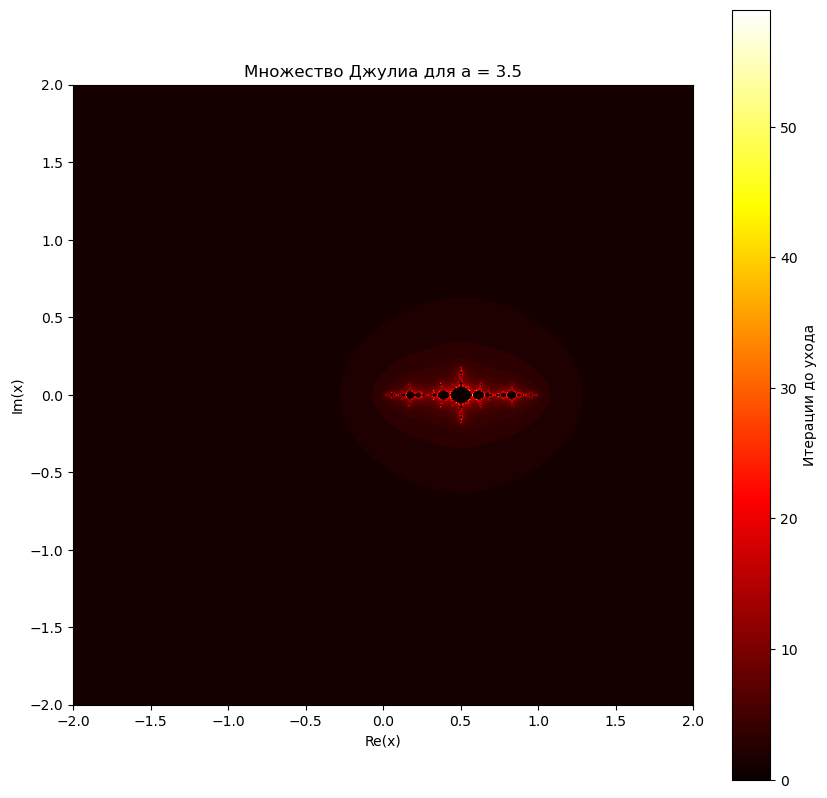

In [58]:
draw_julia_set(3.5, [-2, 2], [-2, 2])

### a = 3.8 (хаотический режим) ###

/tmp/ipykernel_11479/1428469888.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
/tmp/ipykernel_11479/1428469888.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


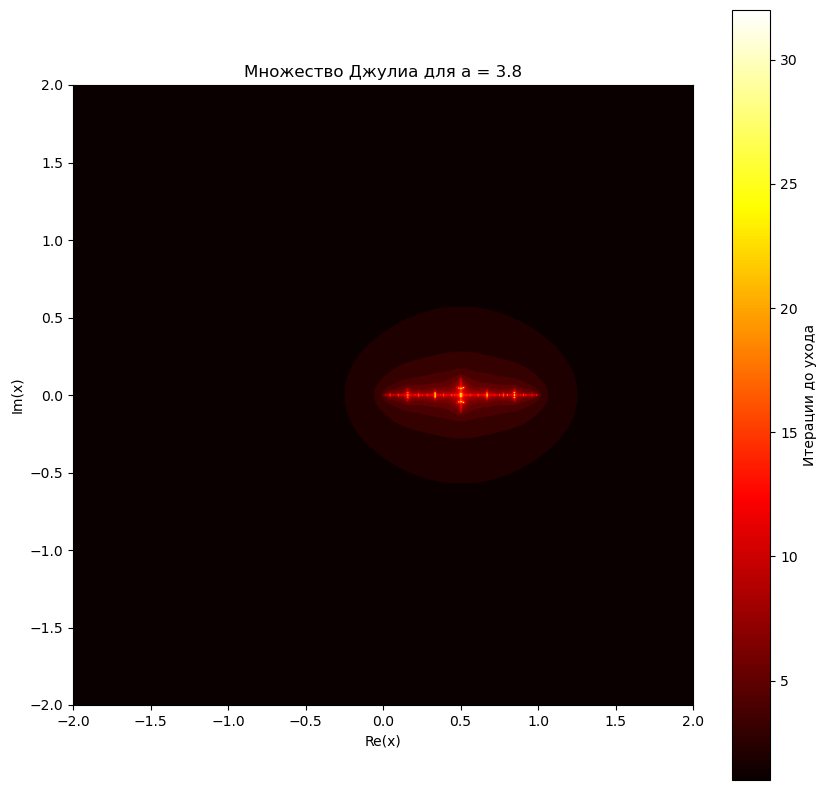

In [59]:
draw_julia_set(3.8, [-2, 2], [-2, 2])

### a = 4 (граница устойчивости) ###

In [ ]:
draw_julia_set(4, [-2, 2], [-2, 2])

Особенно интересно смотреть на комплексные значения параметра a:

### a = 3 + 0.5i (комплексный параметр) ###

/tmp/ipykernel_11479/1428469888.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
/tmp/ipykernel_11479/1428469888.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


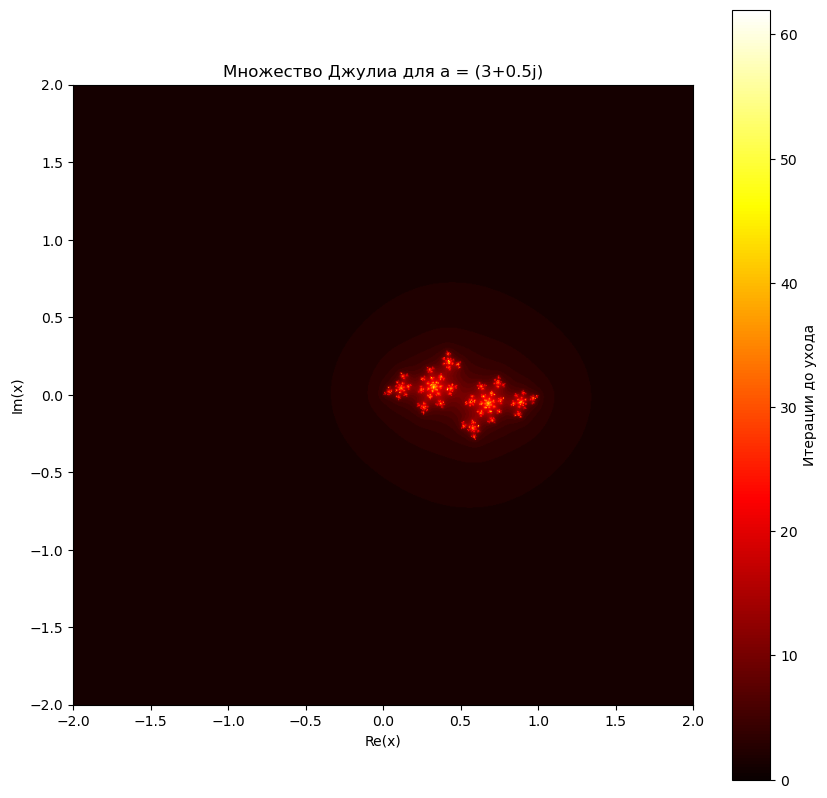

In [60]:
draw_julia_set(3 + 0.5j, [-2, 2], [-2, 2])

### a = 2 + 1i (комплексный параметр) ###

/tmp/ipykernel_11479/1428469888.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
/tmp/ipykernel_11479/1428469888.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


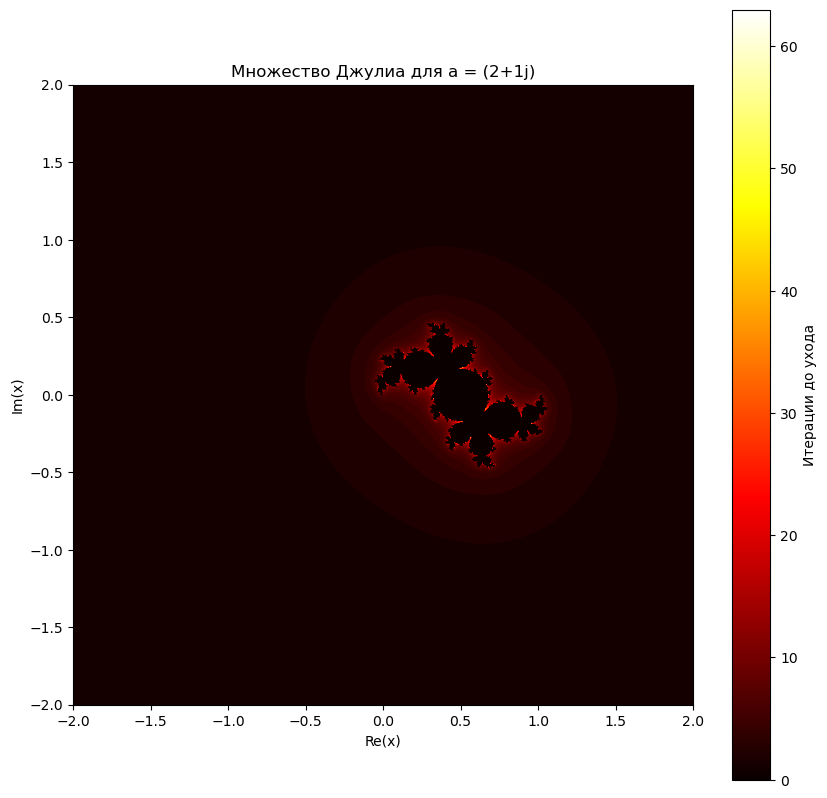

In [61]:
draw_julia_set(2 + 1j, [-2, 2], [-2, 2])

Можно заметить, что структура множества Джулиа связана с поведением процесса:
- В области стабильности множество имеет простую связную структуру
- В области биффуркаций появляются сложные фрактальные структуры
- В хаотическом режиме множество становится несвязным (пыль Кантора)

Это демонстрирует глубокую связь между динамикой процесса и геометрией множества Джулиа.

## Глава шестая. Показатель Ляпунова

*Показатель Ляпунова* - это количественная мера хаотичности динамической системы.

Он измеряет среднюю скорость расхождения близких траекторий в фазовом пространстве.

Для одномерного отображения x_{n+1} = f(x_n, a) показатель Ляпунова определяется как:

λ = lim (1/N) Σ ln|f'(x_n, a)|

где f'(x, a) - производная функции f по x.

**Интерпретация:**
- λ < 0: траектории сходятся → стабильное поведение
- λ = 0: граница устойчивости
- λ > 0: траектории расходятся → хаотическое поведение

Для нашего процесса f(x, a) = a*x*(1-x) производная равна:
f'(x, a) = a*(1 - 2*x)

In [62]:
def lyapunov_exponent(process, a, x0=0.5, n_skip=100, n_steps=1000):
    """
    Вычисляет показатель Ляпунова для процесса
    
    Args:
        process: функция процесса f(x, a)
        a: параметр процесса
        x0: начальное значение
        n_skip: количество шагов для пропуска (установление режима)
        n_steps: количество шагов для усреднения
    
    Returns:
        λ: показатель Ляпунова
    """
    x = x0
    
    # Пропускаем начальный переходный процесс
    for _ in range(n_skip):
        x = process(x, a)
        if abs(x) > 1e10:
            return float('inf')
    
    # Вычисляем сумму логарифмов производных
    lyap_sum = 0
    
    for _ in range(n_steps):
        x = process(x, a)
        
        # Производная f(x, a) = a*x*(1-x) равна a*(1-2*x)
        derivative = abs(a * (1 - 2 * x))
        
        if derivative > 0:
            lyap_sum += np.log(derivative)
        
        if abs(x) > 1e10:
            return float('inf')
    
    return lyap_sum / n_steps

Вычислим показатель Ляпунова для нескольких характерных значений a:

In [63]:
test_values = [1.5, 2.0, 2.5, 3.0, 3.2, 3.5, 3.57, 3.7, 3.8, 3.9, 4.0]

print("\nПоказатели Ляпунова для различных значений a:")
print("-" * 50)
for a in test_values:
    lyap = lyapunov_exponent(process, a, X0)
    print(f"a = {a:4.2f}  →  λ = {lyap:8.5f}  {'(хаос)' if lyap > 0 else '(порядок)'}")


Показатели Ляпунова для различных значений a:
--------------------------------------------------
a = 1.50  →  λ = -0.69315  (порядок)
a = 2.00  →  λ =  0.00000  (порядок)
a = 2.50  →  λ = -0.69315  (порядок)
a = 3.00  →  λ = -0.00208  (порядок)
a = 3.20  →  λ = -0.91629  (порядок)
a = 3.50  →  λ = -0.87251  (порядок)
a = 3.57  →  λ =  0.01179  (хаос)
a = 3.70  →  λ =  0.32122  (хаос)
a = 3.80  →  λ =  0.44654  (хаос)
a = 3.90  →  λ =  0.50149  (хаос)
a = 4.00  →  λ =  0.69313  (хаос)


Построим график показателя Ляпунова в зависимости от параметра a:

In [64]:
def draw_lyapunov_chart(a_range, x0, process, n_points=500):
    """
    Рисует график показателя Ляпунова в зависимости от параметра a
    """
    a_values = np.linspace(*a_range, n_points)
    lyap_values = []
    
    for a in a_values:
        lyap = lyapunov_exponent(process, a, x0)
        lyap_values.append(lyap)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(a_values, lyap_values, 'b-', linewidth=0.5)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=1, label='λ = 0')
    ax.grid(True, alpha=0.3)
    
    ax.set_xlabel('Параметр a', fontsize=12)
    ax.set_ylabel('Показатель Ляпунова λ', fontsize=12)
    ax.set_title('Показатель Ляпунова для логистического отображения', fontsize=14)
    
    # Закрашиваем области
    ax.fill_between(a_values, lyap_values, 0, where=np.array(lyap_values) > 0, 
                     alpha=0.3, color='red', label='Хаос (λ > 0)')
    ax.fill_between(a_values, lyap_values, 0, where=np.array(lyap_values) <= 0, 
                     alpha=0.3, color='green', label='Порядок (λ < 0)')
    
    ax.legend()
    plt.show()

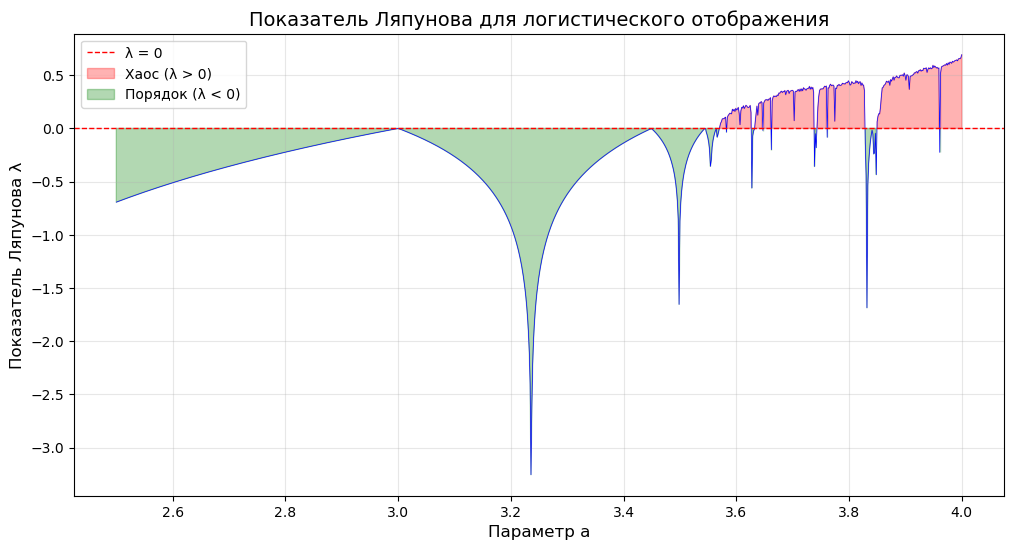

In [65]:
draw_lyapunov_chart([2.5, 4.0], X0, process, n_points=1000)

График показателя Ляпунова наглядно демонстрирует переход от порядка к хаосу:

1. **При a < 3**: λ < 0, система стабильна (сходится к неподвижной точке)

2. **При 3 < a < 3.57**: λ колеблется около нуля, возникают окна периодичности 
   (каскад биффуркаций)

3. **При a > 3.57**: λ > 0 в большинстве случаев, система демонстрирует хаотическое поведение

4. **Окна периодичности**: видны провалы λ < 0 внутри хаотической области 
   (например, около a ≈ 3.83) - это "островки порядка" в хаосе

Интересно сравнить график показателя Ляпунова с диаграммой орбит:

Создадим комбинированную визуализацию:

In [66]:
def draw_combined_chart(a_range, x0, process, n_points=500):
    """
    Рисует совмещенную диаграмму орбит и показателя Ляпунова
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Верхний график - диаграмма орбит
    a_values = np.linspace(*a_range, n_points)
    As = []
    Xs = []
    
    for a in a_values:
        for x in orbit(process, a, x0):
            As.append(a)
            Xs.append(x)
    
    ax1.plot(As, Xs, 'b,', markersize=0.5)
    ax1.set_ylabel('x (орбита)', fontsize=12)
    ax1.set_title('Диаграмма орбит и показатель Ляпунова', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Нижний график - показатель Ляпунова
    lyap_values = []
    for a in a_values:
        lyap = lyapunov_exponent(process, a, x0)
        lyap_values.append(lyap)
    
    ax2.plot(a_values, lyap_values, 'r-', linewidth=0.8)
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax2.fill_between(a_values, lyap_values, 0, where=np.array(lyap_values) > 0, 
                      alpha=0.3, color='red', label='Хаос')
    ax2.fill_between(a_values, lyap_values, 0, where=np.array(lyap_values) <= 0, 
                      alpha=0.3, color='green', label='Порядок')
    
    ax2.set_xlabel('Параметр a', fontsize=12)
    ax2.set_ylabel('Показатель Ляпунова λ', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

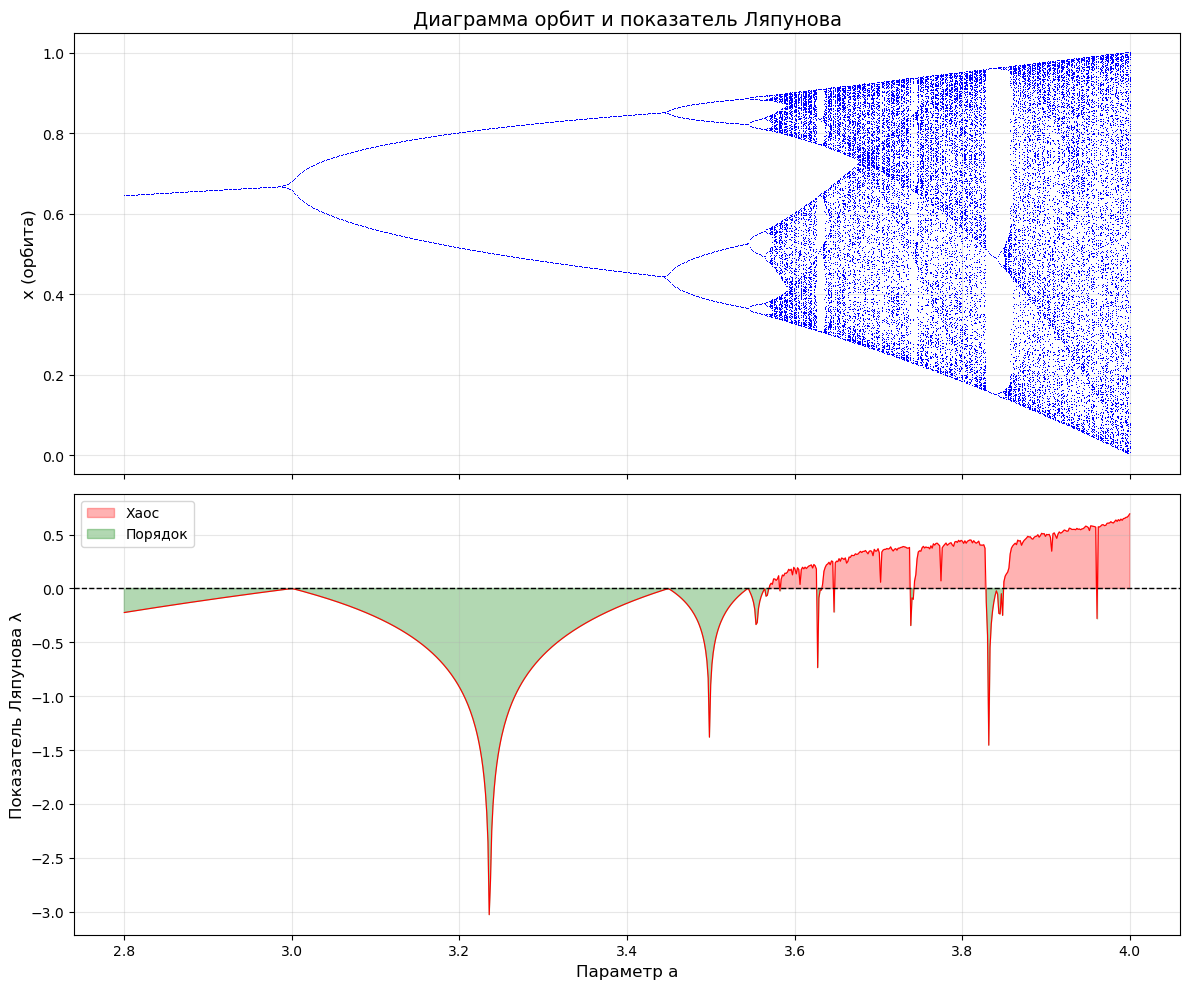

In [67]:
draw_combined_chart([2.8, 4.0], X0, process, n_points=800)

На этой комбинированной визуализации прекрасно видна связь между:
- **Структурой орбит** (верхний график)
- **Хаотичностью системы** (нижний график)

**Ключевые наблюдения:**

1. В точках биффуркаций показатель Ляпунова проходит через ноль
2. В окнах периодичности (где орбита имеет конечное число точек) λ < 0
3. В областях "густого заполнения" орбиты λ > 0 (хаос)
4. Чем больше λ, тем сильнее хаотичность

Показатель Ляпунова - это универсальный инструмент диагностики хаоса, 
применимый к любым динамическим системам!

## Заключение

Мы прошли путь от простого итерационного процесса x → a·x·(1-x) 
до глубоких концепций теории хаоса:

**1. Детерминированный хаос:** 
   Простые детерминированные правила могут порождать непредсказуемое поведение

**2. Каскад биффуркаций:** 
   Переход от порядка к хаосу происходит через последовательность удвоений периода

**3. Универсальность:**
   Константы Фейгенбаума появляются в любых системах с аналогичной динамикой

**4. Фрактальная структура:**
   Граница между порядком и хаосом имеет самоподобную структуру

**5. Чувствительность к начальным условиям:**
   Показатель Ляпунова количественно измеряет экспоненциальное расхождение траекторий

**6. Окна периодичности:**
   Даже в глубоком хаосе существуют "островки порядка"

Эти принципы применимы далеко за пределами математики: от популяционной динамики 
до турбулентности, от экономических циклов до нейронных сетей, от погоды до 
квантовой механики.

**Главный урок теории хаоса:** Мир не делится на "простой и предсказуемый" или 
"случайный и беспорядочный". Существует третья категория - *детерминированный хаос* - 
системы, подчиняющиеся строгим законам, но демонстрирующие непредсказуемое поведение.

Простое уравнение x_{n+1} = a·x_n·(1-x_n) содержит в себе бесконечную сложность. 
Это одновременно и урок скромности (мы не можем предсказать даже простые системы), 
и урок вдохновения (простота может содержать бесконечную красоту).